# Исследование биоинспирированной модификации механизма внимания в архитектуре трансформера на основе алгоритма SMA

### Импорты и настройка окружения

Подключаются все необходимые библиотеки для работы с нейронными сетями, обработки данных, визуализации результатов и загрузки датасетов. Определяется устройство вычислений (CPU или GPU), задаются основные параметры и фиксируются генераторы случайных чисел для воспроизводимости результатов.

In [ ]:
# !pip install datasets transformers -q

In [ ]:
!pip install datasets==2.16.1 transformers==4.38.2 huggingface_hub==0.20.3 numpy==1.26.4

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
import random
from torch.utils.data import DataLoader, Subset
from datasets import load_dataset
from transformers import AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

VOCAB_SIZE = 30522
N_EPOCHS   = 5
SEEDS      = [42, 123, 7, 256, 999]
NOISE_LEVELS      = [0.0, 0.1, 0.2, 0.5, 0.8, 1.0, 1.5, 2.0]
OUTLIER_AMPLITUDES = [0, 1, 2, 5, 10, 20, 50]
COLORS = {'softmax': 'blue', 'sma_c': 'red', 'sma_a': 'green'}
LABELS = {'softmax': 'Softmax', 'sma_c': 'SMA-C', 'sma_a': 'SMA-A'}

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

Устройство: cuda
GPU: Tesla T4


### Механизмы внимания

SoftmaxAttention: классическая реализация механизма Scaled Dot-Product Attention, используемая в качестве базовой линии для оценки эффективности. Веса внимания вычисляются с помощью функции softmax, которая преобразует оценки сходства в вероятностное распределение с суммой весов, равной единице.

SMAAttention (упрощённая версия): модификация механизма внимания, основанная на принципах алгоритма слизевика. Вместо экспоненциального взвешивания применяется нормировка через сигмоидальное сглаживание ($tanh$) отклонений от среднего значения. Это позволяет модели более гибко распределять веса и ограничивать влияние аномальных выбросов в данных, что потенциально повышает устойчивость. beta — обучаемый параметр, начальное значение 1.0.

SMAAttentionA: логика биоинспирированного внимания, более близкая к оригинальному SMA. Веса формируются на основе относительного положения оценки сходства между минимальным и максимальным значениями строки с использованием логарифмического преобразования. Дополнительно учитывается положение элемента относительно медианы, что позволяет усиливать более значимые связи и ослаблять менее значимые без применения экспоненциального взвешивания.

In [ ]:
class SoftmaxAttention(nn.Module):
    """Стандартный Scaled Dot-Product Attention."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        w = torch.nan_to_num(F.softmax(scores, dim=-1), nan=0.0)
        out = torch.matmul(self.dropout(w), V)
        return self.W_o(out.transpose(1, 2).contiguous().view(B, T, self.d_model))


class SMAAttentionC(nn.Module):
    """Биоинспирированный механизм внимания SMA (упрощенный вариант)."""
    def __init__(self, d_model, n_heads, dropout=0.1, beta=1.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.beta = nn.Parameter(torch.tensor(beta))
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def sma_weights(self, scores, mask=None):
        """
        Вычисляет SMA-веса вместо softmax.
        scores: (B, n_heads, T, T)
        mask:   (B, 1, 1, T) — 1 для реальных токенов, 0 для паддинга
        return: (B, n_heads, T, T) нормированные веса
        """
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        mu    = scores.mean(dim=-1, keepdim=True)
        sigma = scores.std(dim=-1, keepdim=True)
        z     = (scores - mu) / (sigma + 1e-8)
        W     = 1.0 + torch.tanh(self.beta * z)
        if mask is not None:
            W = W.masked_fill(mask == 0, 0.0)
        return W / (W.sum(dim=-1, keepdim=True) + 1e-8)

    def forward(self, x, mask=None):
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        w = self.dropout(self.sma_weights(scores, mask))
        out = torch.matmul(w, V)
        return self.W_o(out.transpose(1, 2).contiguous().view(B, T, self.d_model))


class SMAAttentionA(nn.Module):
    """Биоинспирированный механизм внимания SMA с логарифмическим взвешиванием."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        bF     = scores.detach().max(dim=-1, keepdim=True).values
        wF     = scores.detach().min(dim=-1, keepdim=True).values
        median = scores.detach().median(dim=-1, keepdim=True).values
        log_term = torch.log((bF - scores) / (bF - wF + 1e-8) + 1)
        sign = torch.sign(scores.detach() - median).float()
        sign = torch.where(sign == 0, torch.ones_like(sign), sign)
        W = 1.0 + sign * log_term
        if mask is not None:
            W = W.masked_fill(mask == 0, 0.0)
        w = self.dropout(W / (W.sum(dim=-1, keepdim=True) + 1e-8))
        out = torch.matmul(w, V)
        return self.W_o(out.transpose(1, 2).contiguous().view(B, T, self.d_model))

### Архитектура нейросети

TransformerBlock: стандартный блок трансформера, состоит из слоя внимания, двух residual-соединений (skip connections), двух слоёв нормализации (LayerNorm) и двухслойной полносвязной сети (Feed-Forward Network). В качестве функции активации используется GELU. Параметр atype позволяет переключаться между реализациями механизмов внимания Softmax, SMA-C и SMA-A без изменения остальных компонентов модели.

TextClassifier: полноценная модель-классификатор текста, включает слой токенных эмбеддингов, слой позиционных эмбеддингов и два последовательно соединённых блока трансформера (n_layers=2). Размерность скрытых представлений составляет 128 (d_model=128), используется 4 головы внимания (n_heads=4), размер скрытого слоя Feed-Forward сети равен 256 (d_ff=256). Особенностью реализации является возможность добавления гауссовского шума в эмбеддинги перед подачей данных в трансформер. Это позволяет искусственно искажать входные представления и исследовать устойчивость механизмов внимания к шуму и выбросам.

В конце выполняется дополнительная проверка корректности вычисления градиентов, чтобы убедиться, что ошибка успешно распространяется через все слои сети и обучение модели будет происходить корректно. Для каждого варианта внимания создаётся небольшая тестовая модель, выполняется прямой и обратный проход, после чего проверяется, получают ли все обучаемые параметры ненулевые градиенты.

In [ ]:
class TransformerBlock(nn.Module):
   """Стандартный блок Трансформера с возможностью выбора типа внимания."""
   def __init__(self, d_model, n_heads, d_ff, dropout=0.1, atype='softmax'):
        super().__init__()
        if atype == 'softmax':
            self.attention = SoftmaxAttention(d_model, n_heads, dropout)
        elif atype == 'sma_c':
            self.attention = SMAAttentionC(d_model, n_heads, dropout)
        elif atype == 'sma_a':
            self.attention = SMAAttentionA(d_model, n_heads, dropout)
        else:
            raise ValueError(f'Неизвестный тип: {atype}')
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

   def forward(self, x, mask=None):
        x = self.norm1(x + self.attention(x, mask))
        x = self.norm2(x + self.ff(x))
        return x


class TextClassifier(nn.Module):
    """Трансформер-классификатор с поддержкой инъекции шума в эмбеддинги."""
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=2,
                 d_ff=256, max_len=128, n_classes=2, dropout=0.1, atype='softmax'):
        super().__init__()
        self.embedding     = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, d_model)
        self.dropout       = nn.Dropout(dropout)
        self.layers        = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout, atype)
            for _ in range(n_layers)
        ])
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, input_ids, attention_mask=None, noise_std=0.0):
        B, T = input_ids.shape
        pos  = torch.arange(T, device=input_ids.device).unsqueeze(0)
        x    = self.embedding(input_ids) + self.pos_embedding(pos)
        if noise_std > 0.0:
            noise = torch.randn_like(x) * noise_std
            if attention_mask is not None:
                noise = noise * attention_mask.unsqueeze(-1).float()
            x = x + noise
        x    = self.dropout(x)
        mask = attention_mask.unsqueeze(1).unsqueeze(2) if attention_mask is not None else None
        for layer in self.layers:
            x = layer(x, mask)
        if attention_mask is not None:
            m = attention_mask.unsqueeze(-1).float()
            x = (x * m).sum(1) / m.sum(1).clamp(min=1)
        else:
            x = x.mean(1)
        return self.classifier(x)


# Быстрая проверка архитектур и градиентов
def check_gradients():
    print('Проверка градиентов:')
    for atype in ['softmax', 'sma_c', 'sma_a']:
        m = TextClassifier(100, atype=atype)
        loss = F.cross_entropy(
            m(torch.randint(0, 100, (2, 16)), torch.ones(2, 16)),
            torch.randint(0, 2, (2,))
        )
        loss.backward()
        ok = all(p.grad is not None and p.grad.abs().sum() > 0
                 for p in m.parameters() if p.requires_grad)
        print(f'  {atype}: {"OK" if ok else "Ошибка"}')

check_gradients()

Проверка градиентов:
  softmax: OK
  sma_c: OK
  sma_a: OK


### Загрузка данных

Загружается предобученный токенизатор BERT (`bert-base-uncased`), который будет преобразовывать тексты в числовые токены. Далее определяется универсальная функция `make_loaders`, которая загружает датасет, токенизирует тексты, ограничивает длину последовательностей и формирует PyTorch DataLoader для обучения и тестирования.

Подготавливаются три датасета для задач классификации текстов: SST-2 (анализ тональности коротких предложений, 2 класса), AG News (классификация новостей по тематике, 4 класса) и IMDB (анализ отзывов на фильмы, 2 класса).

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def make_loaders(dataset_name, text_field, max_len, batch_size,
                 train_split='train', test_split='validation',
                 train_size=None, test_size=None):
    """Универсальная загрузка и токенизация датасета."""
    ds = load_dataset(dataset_name) if dataset_name != 'glue_sst2' \
        else load_dataset('glue', 'sst2')

    def tokenize(examples):
        return tokenizer(examples[text_field], padding='max_length',
                         truncation=True, max_length=max_len)

    train_ds = ds[train_split].map(tokenize, batched=True)
    test_ds  = ds[test_split].map(tokenize,  batched=True)
    for d in [train_ds, test_ds]:
        d.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

    if train_size:
        idx = random.sample(range(len(train_ds)), min(train_size, len(train_ds)))
        train_ds = Subset(train_ds, idx)
    if test_size:
        idx = random.sample(range(len(test_ds)), min(test_size, len(test_ds)))
        test_ds = Subset(test_ds, idx)

    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2),
            DataLoader(test_ds,  batch_size=batch_size, num_workers=2))

# SST-2: короткие предложения, 2 класса
sst2_train_loader, sst2_val_loader = make_loaders(
    'glue_sst2', 'sentence', max_len=128, batch_size=64,
    train_split='train', test_split='validation'
)
print(f'SST-2  — train: {len(sst2_train_loader)} батчей, val: {len(sst2_val_loader)}')

# AG News: тематика новостей, 4 класса
ag_train_loader, ag_test_loader = make_loaders(
    'ag_news', 'text', max_len=128, batch_size=64,
    train_split='train', test_split='test',
    train_size=40000, test_size=7600
)
print(f'AG News — train: {len(ag_train_loader)} батчей, test: {len(ag_test_loader)}')

# IMDB: длинные отзывы, 2 класса
imdb_train_loader, imdb_test_loader = make_loaders(
    'imdb', 'text', max_len=256, batch_size=32,
    train_split='train', test_split='test',
    train_size=15000, test_size=5000
)
print(f'IMDB — train: {len(imdb_train_loader)} батчей, test: {len(imdb_test_loader)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/872 [00:00<?, ? examples/s]

SST-2  — train: 1053 батчей, val: 14
AG News — train: 625 батчей, test: 119


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

IMDB — train: 469 батчей, test: 157


### Функции обучения и оценки

Обучение модели выполняется функцией `train_one_epoch`, которая переводит модель в режим обучения, проходит по батчам даталоадера, выполняет прямой и обратный проход, применяет clipping градиентов для стабильности и обновляет параметры через оптимизатор и scheduler.

Функция `evaluate` используется для оценки качества модели на валидационном/тестовом наборе: переводит модель в режим inference, считает loss и accuracy без обновления градиентов, также поддерживает добавление шума в предсказания для анализа устойчивости.

`evaluate_outlier` искусственно вносит шум в случайную позицию токенов внутри последовательности, чтобы проверить устойчивость модели к выбросам на уровне входных представлений.

`run_experiment` реализует полный цикл эксперимента: инициализацию модели, обучение по эпохам, контроль качества на тесте, измерение времени обучения и последующую проверку устойчивости к разным уровням шума. В конце собираются результаты для анализа.

`get_stats` агрегирует результаты нескольких запусков, возвращая среднее значение и стандартное отклонение по метрикам.


In [ ]:
def train_one_epoch(model, loader, optimizer, scheduler):
    model.train()
    for batch in loader:
        ids = batch['input_ids'].to(device)
        msk = batch['attention_mask'].to(device)
        lbl = batch['label'].to(device)
        optimizer.zero_grad()
        F.cross_entropy(model(ids, msk), lbl).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()


@torch.no_grad()
def evaluate(model, loader, noise_std=0.0):
    """Возвращает accuracy и loss."""
    model.eval()
    correct, total_loss, total = 0, 0.0, 0
    for batch in loader:
        ids     = batch['input_ids'].to(device)
        msk     = batch['attention_mask'].to(device)
        lbl     = batch['label'].to(device)
        logits  = model(ids, msk, noise_std)
        total_loss += F.cross_entropy(logits, lbl).item() * lbl.size(0)
        correct    += (logits.argmax(-1) == lbl).sum().item()
        total      += lbl.size(0)
    return correct / total, total_loss / total


@torch.no_grad()
def evaluate_outlier(model, loader, amplitude=0.0):
    """Оценка с целевым выбросом: один случайный токен на amplitude."""
    model.eval()
    correct, total = 0, 0
    for batch in loader:
        ids = batch['input_ids'].to(device)
        msk = batch['attention_mask'].to(device)
        lbl = batch['label'].to(device)
        if amplitude > 0:
            B, T   = ids.shape
            pos    = torch.arange(T, device=device).unsqueeze(0)
            x      = model.embedding(ids) + model.pos_embedding(pos)
            lengths = msk.sum(1).long()
            noise  = torch.randn(B, x.size(-1), device=device) * amplitude
            for b in range(B):
                p = torch.randint(0, lengths[b].item(), (1,)).item()
                x[b, p] += noise[b]
            x    = model.dropout(x)
            mask4 = msk.unsqueeze(1).unsqueeze(2)
            for layer in model.layers:
                x = layer(x, mask4)
            m_exp  = msk.unsqueeze(-1).float()
            x      = (x * m_exp).sum(1) / m_exp.sum(1).clamp(min=1)
            logits = model.classifier(x)
        else:
            logits = model(ids, msk)
        correct += (logits.argmax(-1) == lbl).sum().item()
        total   += lbl.size(0)
    return correct / total


def run_experiment(atype, seed, train_loader, test_loader,
                   n_classes, max_len, n_epochs=N_EPOCHS):
    """Полный цикл эксперимента: инициализация, обучение, оценка при шуме."""
    set_seed(seed)
    model = TextClassifier(
        VOCAB_SIZE, 128, 4, 2, 256, max_len, n_classes, 0.1, atype
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=1e-3,
        total_steps=len(train_loader) * n_epochs
    )

    # Замер времени обучения
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t_start = time.perf_counter()

    history = []
    for epoch in range(n_epochs):
        train_one_epoch(model, train_loader, optimizer, scheduler)
        acc, loss = evaluate(model, test_loader)
        history.append((loss, acc))
        print(f'  [{atype}] Epoch {epoch+1}/{n_epochs} '
              f'val_loss={loss:.4f} val_acc={acc:.4f}')

    if device.type == 'cuda':
        torch.cuda.synchronize()
    train_time = time.perf_counter() - t_start

    noise_accs = [evaluate(model, test_loader, n)[0] for n in NOISE_LEVELS]
    return model, history, noise_accs, train_time


def get_stats(results_list):
    a = np.array(results_list)
    return a.mean(0), a.std(0)

### Функции анализа и визуализации

`plot_training_curves` отображает динамику функции потерь и accuracy по эпохам для разных типов моделей, позволяя сравнить их поведение в процессе обучения.

`plot_noise_robustness` показывает, как точность модели меняется при добавлении гауссовского шума в эмбеддинги, а также отображает разброс результатов по нескольким запускам (mean±std).

`plot_outlier` визуализирует устойчивость моделей к целевому выбросу (случайному сильному искажению одного токена в последовательности).

`plot_summary` объединяет результаты по нескольким датасетам и позволяет сравнить устойчивость моделей в разных задачах в одном графике.

`print_results_table` выводит табличное сравнение точности при разных уровнях шума, а также оценивает степень деградации качества при максимальном шуме относительно базовой модели.

`print_time_comparison` сравнивает среднее время обучения моделей и показывает, насколько каждая архитектура медленнее или быстрее базовой (Softmax).

`get_attention_entropy` вычисляет среднюю энтропию распределений внимания в первом слое трансформера, что позволяет оценить разреженность или уверенность attention-механизма и его поведение при шуме.


In [ ]:
def plot_training_curves(histories, title=''):
    """histories: dict {atype: [(loss, acc), ...]}"""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ep = range(1, len(next(iter(histories.values()))) + 1)
    for atype, h in histories.items():
        axes[0].plot(ep, [x[0] for x in h], '-o', color=COLORS[atype],
                     label=LABELS[atype], lw=2)
        axes[1].plot(ep, [x[1] for x in h], '-o', color=COLORS[atype],
                     label=LABELS[atype], lw=2)
    for ax, ylabel in [(axes[0], 'Loss'), (axes[1], 'Accuracy')]:
        ax.set_title(f'Val {ylabel} по эпохам' + (f' — {title}' if title else ''))
        ax.set_xlabel('Эпоха'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'training_{title.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def plot_noise_robustness(stats_dict, title='', save_name='noise.png'):
    """stats_dict: dict {atype: (mean_arr, std_arr)}"""
    fig, ax = plt.subplots(figsize=(9, 5))
    for atype, (m, s) in stats_dict.items():
        ax.plot(NOISE_LEVELS, m, '-o', color=COLORS[atype],
                label=LABELS[atype], lw=2.5, ms=7)
        ax.fill_between(NOISE_LEVELS, m-s, m+s, alpha=0.15, color=COLORS[atype])
    ax.set_title(f'Accuracy vs шум (mean±std, {len(SEEDS)} seed)'
                 + (f'\n{title}' if title else ''))
    ax.set_xlabel('σ шума в embeddings'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


def plot_outlier(outlier_dict, title='', save_name='outlier.png'):
    """outlier_dict: dict {atype: [acc, ...]} по OUTLIER_AMPLITUDES"""
    fig, ax = plt.subplots(figsize=(9, 5))
    for atype, accs in outlier_dict.items():
        ax.plot(OUTLIER_AMPLITUDES, accs, '-o', color=COLORS[atype],
                label=LABELS[atype], lw=2.5, ms=7)
    ax.set_title('Устойчивость к целевому выбросу'
                 + (f'\n{title}' if title else ''))
    ax.set_xlabel('Амплитуда выброса'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


def plot_summary(all_stats, title=''):
    """all_stats: dict {ds_name: {atype: (mean, std)}}"""
    n = len(all_stats)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]
    for ax, (ds_name, stats) in zip(axes, all_stats.items()):
        for atype, (m, s) in stats.items():
            ax.plot(NOISE_LEVELS, m, '-o', color=COLORS[atype],
                    label=LABELS[atype], lw=2.5, ms=6)
            ax.fill_between(NOISE_LEVELS, m-s, m+s, alpha=0.12, color=COLORS[atype])
        ax.set_title(ds_name, fontsize=11)
        ax.set_xlabel('σ шума'); ax.set_ylabel('Accuracy')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.suptitle(title or f'Устойчивость к шуму ({len(SEEDS)} запусков)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('summary_datasets.png', dpi=150, bbox_inches='tight')
    plt.show()


def print_results_table(stats_dict, noise_levels=None):
    """stats_dict: dict {atype: (mean_arr, std_arr)}"""
    nl = noise_levels or NOISE_LEVELS
    print(f'{"σ":<6}', end='')
    for atype in stats_dict:
        print(f'  {LABELS[atype]:^22}', end='')
    print('\n' + '-'*70)
    for i, n in enumerate(nl):
        print(f'{n:<6.1f}', end='')
        for atype, (m, s) in stats_dict.items():
            print(f'  {m[i]:.4f} ± {s[i]:.4f}     ', end='')
        print()
    print('='*70)
    base_deg = stats_dict['softmax'][0][0] - stats_dict['softmax'][0][-1]
    print('\nДеградация при σ=2.0:')
    for atype, (m, _) in stats_dict.items():
        deg = m[0] - m[-1]
        vs  = (base_deg - deg) / base_deg * 100 if base_deg > 0 else 0
        print(f'  {LABELS[atype]}: -{deg:.4f}  ({vs:+.1f}% vs Softmax)')


def print_time_comparison(times_dict):
    """times_dict: dict {atype: [time_seed1, time_seed2, ...]}"""
    print('\nВремя обучения (среднее по seed):')
    base_time = np.mean(times_dict['softmax'])
    for atype, times in times_dict.items():
        m, s = np.mean(times), np.std(times)
        overhead = (m / base_time - 1) * 100
        print(f'  {LABELS[atype]}: {m:.1f} ± {s:.1f} с  '
              f'({"+" if overhead > 0 else ""}{overhead:.1f}% vs Softmax)')


def get_attention_entropy(model, loader, noise_std=0.0, n_batches=5):
    """Средняя энтропия весов внимания первого слоя."""
    model.eval()
    vals = []
    for i, batch in enumerate(loader):
        if i >= n_batches: break
        ids = batch['input_ids'].to(device)
        msk = batch['attention_mask'].to(device)
        B, T = ids.shape
        with torch.no_grad():
            pos  = torch.arange(T, device=device).unsqueeze(0)
            x    = model.embedding(ids) + model.pos_embedding(pos)
            if noise_std > 0:
                x = x + torch.randn_like(x) * noise_std * msk.unsqueeze(-1).float()
            x     = model.dropout(x)
            attn  = model.layers[0].attention
            mask4 = msk.unsqueeze(1).unsqueeze(2)
            Q = attn.W_q(x).view(B, T, attn.n_heads, attn.d_k).transpose(1, 2)
            K = attn.W_k(x).view(B, T, attn.n_heads, attn.d_k).transpose(1, 2)
            sc = torch.matmul(Q, K.transpose(-2, -1)) / (attn.d_k ** 0.5)
            if hasattr(attn, 'beta'):             # SMA-C
                w = attn.sma_weights(sc, mask4)
            elif isinstance(attn, SMAAttentionA): # SMA-A
                sc2 = sc.masked_fill(mask4 == 0, -1e9)
                bF  = sc2.detach().max(-1, keepdim=True).values
                wF  = sc2.detach().min(-1, keepdim=True).values
                lt  = torch.log((bF - sc2) / (bF - wF + 1e-8) + 1)
                med = sc2.detach().median(-1, keepdim=True).values
                sg  = torch.sign(sc2.detach() - med).float()
                sg  = torch.where(sg == 0, torch.ones_like(sg), sg)
                W   = (1.0 + sg * lt).masked_fill(mask4 == 0, 0.0)
                w   = W / (W.sum(-1, keepdim=True) + 1e-8)
            else:                                 # Softmax
                sc2 = sc.masked_fill(mask4 == 0, float('-inf'))
                w   = torch.nan_to_num(F.softmax(sc2, dim=-1), nan=0.0)
            H = -(w * torch.log(w + 1e-9)).sum(-1).mean().item()
            vals.append(H)
    return np.mean(vals)

## Датасет SST-2

In [ ]:
print('='*55)
print('ЭКСПЕРИМЕНТ 1: SST-2 (2 класса, короткие тексты)')
print('='*55)

sst2_noise  = {k: [] for k in LABELS}
sst2_times  = {k: [] for k in LABELS}
sst2_last   = {}
sst2_history_seed42 = {}

for seed in SEEDS:
    print(f'\nSeed {seed}')
    for atype in LABELS:
        model, history, noise_accs, t = run_experiment(
            atype, seed,
            sst2_train_loader, sst2_val_loader,
            n_classes=2, max_len=128
        )
        sst2_noise[atype].append(noise_accs)
        sst2_times[atype].append(t)
        sst2_last[atype] = model
        if seed == 42:
            sst2_history_seed42[atype] = history

sst2_stats = {k: get_stats(v) for k, v in sst2_noise.items()}

ЭКСПЕРИМЕНТ 1: SST-2 (2 класса, короткие тексты)

Seed 42
  [softmax] Epoch 1/5 val_loss=0.5733 val_acc=0.6961
  [softmax] Epoch 2/5 val_loss=0.4842 val_acc=0.7787
  [softmax] Epoch 3/5 val_loss=0.5261 val_acc=0.7844
  [softmax] Epoch 4/5 val_loss=0.5236 val_acc=0.8119
  [softmax] Epoch 5/5 val_loss=0.5228 val_acc=0.8096
  [sma_c] Epoch 1/5 val_loss=0.5827 val_acc=0.6892
  [sma_c] Epoch 2/5 val_loss=0.4617 val_acc=0.7890
  [sma_c] Epoch 3/5 val_loss=0.4904 val_acc=0.8039
  [sma_c] Epoch 4/5 val_loss=0.4846 val_acc=0.8177
  [sma_c] Epoch 5/5 val_loss=0.4830 val_acc=0.8119
  [sma_a] Epoch 1/5 val_loss=0.5827 val_acc=0.6892
  [sma_a] Epoch 2/5 val_loss=0.4617 val_acc=0.7890
  [sma_a] Epoch 3/5 val_loss=0.4904 val_acc=0.8039
  [sma_a] Epoch 4/5 val_loss=0.4846 val_acc=0.8177
  [sma_a] Epoch 5/5 val_loss=0.4830 val_acc=0.8119

Seed 123
  [softmax] Epoch 1/5 val_loss=0.5190 val_acc=0.7466
  [softmax] Epoch 2/5 val_loss=0.4430 val_acc=0.8016
  [softmax] Epoch 3/5 val_loss=0.4580 val_acc=0.802

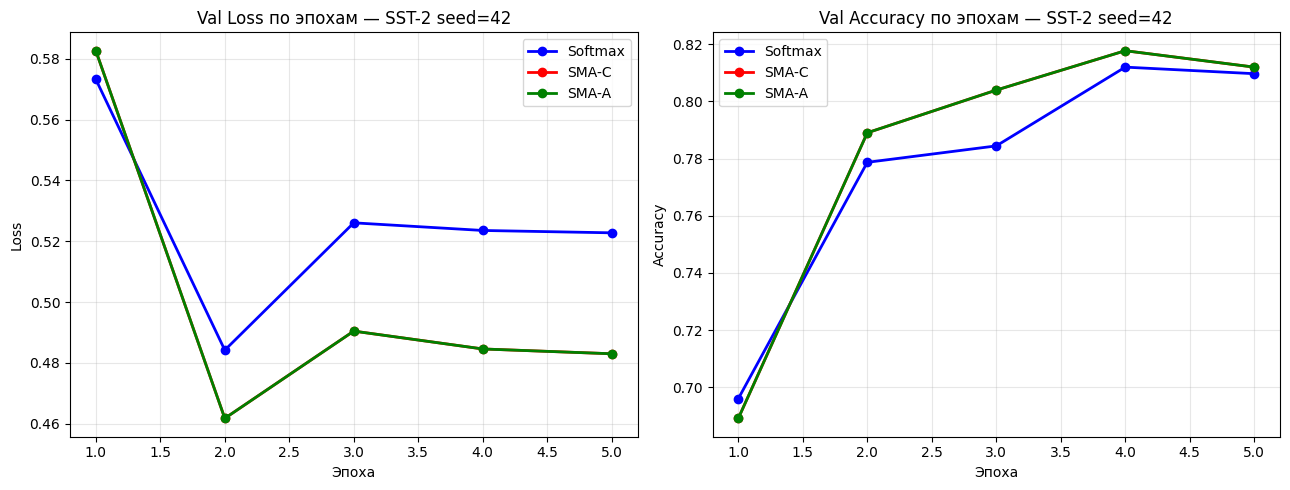

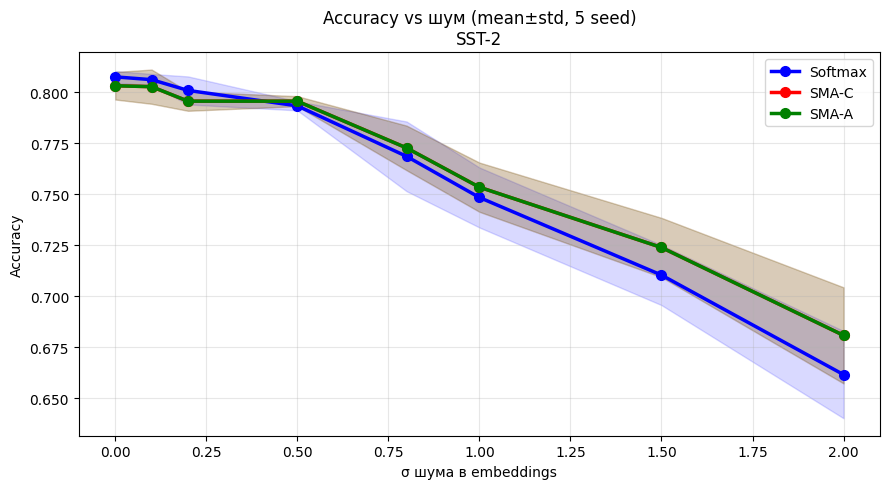

σ              Softmax                  SMA-C                   SMA-A         
----------------------------------------------------------------------
0.0     0.8076 ± 0.0028       0.8032 ± 0.0067       0.8032 ± 0.0067     
0.1     0.8062 ± 0.0028       0.8028 ± 0.0084       0.8028 ± 0.0084     
0.2     0.8009 ± 0.0069       0.7956 ± 0.0047       0.7956 ± 0.0047     
0.5     0.7933 ± 0.0022       0.7956 ± 0.0024       0.7956 ± 0.0024     
0.8     0.7686 ± 0.0171       0.7727 ± 0.0109       0.7727 ± 0.0109     
1.0     0.7484 ± 0.0147       0.7534 ± 0.0121       0.7534 ± 0.0121     
1.5     0.7103 ± 0.0147       0.7239 ± 0.0145       0.7239 ± 0.0145     
2.0     0.6615 ± 0.0214       0.6807 ± 0.0236       0.6807 ± 0.0236     

Деградация при σ=2.0:
  Softmax: -0.1461  (+0.0% vs Softmax)
  SMA-C: -0.1225  (+16.2% vs Softmax)
  SMA-A: -0.1225  (+16.2% vs Softmax)

Время обучения (среднее по seed):
  Softmax: 92.9 ± 2.2 с  (0.0% vs Softmax)
  SMA-C: 134.7 ± 1.2 с  (+44.9% vs Softmax)
  SMA-

In [ ]:
plot_training_curves(sst2_history_seed42, title='SST-2 seed=42')
plot_noise_robustness(sst2_stats, title='SST-2', save_name='sst2_noise.png')
print_results_table(sst2_stats)
print_time_comparison(sst2_times)

## Датасет AG News

In [ ]:
print('='*55)
print('ЭКСПЕРИМЕНТ 2: AG News (4 класса, тематика)')
print('='*55)

ag_noise  = {k: [] for k in LABELS}
ag_times  = {k: [] for k in LABELS}
ag_last   = {}
ag_history_seed42 = {}

for seed in SEEDS:
    print(f'\nSeed {seed}')
    for atype in LABELS:
        model, history, noise_accs, t = run_experiment(
            atype, seed,
            ag_train_loader, ag_test_loader,
            n_classes=4, max_len=128
        )
        ag_noise[atype].append(noise_accs)
        ag_times[atype].append(t)
        ag_last[atype] = model
        if seed == 42:
            ag_history_seed42[atype] = history

ag_stats = {k: get_stats(v) for k, v in ag_noise.items()}

ЭКСПЕРИМЕНТ 2: AG News (4 класса, тематика)

Seed 42
  [softmax] Epoch 1/5 val_loss=0.6097 val_acc=0.7762
  [softmax] Epoch 2/5 val_loss=0.4037 val_acc=0.8593
  [softmax] Epoch 3/5 val_loss=0.3376 val_acc=0.8863
  [softmax] Epoch 4/5 val_loss=0.3356 val_acc=0.8901
  [softmax] Epoch 5/5 val_loss=0.3409 val_acc=0.8911
  [sma_c] Epoch 1/5 val_loss=0.6637 val_acc=0.7493
  [sma_c] Epoch 2/5 val_loss=0.4090 val_acc=0.8532
  [sma_c] Epoch 3/5 val_loss=0.3333 val_acc=0.8882
  [sma_c] Epoch 4/5 val_loss=0.3225 val_acc=0.8922
  [sma_c] Epoch 5/5 val_loss=0.3207 val_acc=0.8933
  [sma_a] Epoch 1/5 val_loss=0.6608 val_acc=0.7513
  [sma_a] Epoch 2/5 val_loss=0.4068 val_acc=0.8545
  [sma_a] Epoch 3/5 val_loss=0.3336 val_acc=0.8879
  [sma_a] Epoch 4/5 val_loss=0.3223 val_acc=0.8917
  [sma_a] Epoch 5/5 val_loss=0.3206 val_acc=0.8932

Seed 123
  [softmax] Epoch 1/5 val_loss=0.6065 val_acc=0.7729
  [softmax] Epoch 2/5 val_loss=0.4011 val_acc=0.8612
  [softmax] Epoch 3/5 val_loss=0.3485 val_acc=0.8813
  [

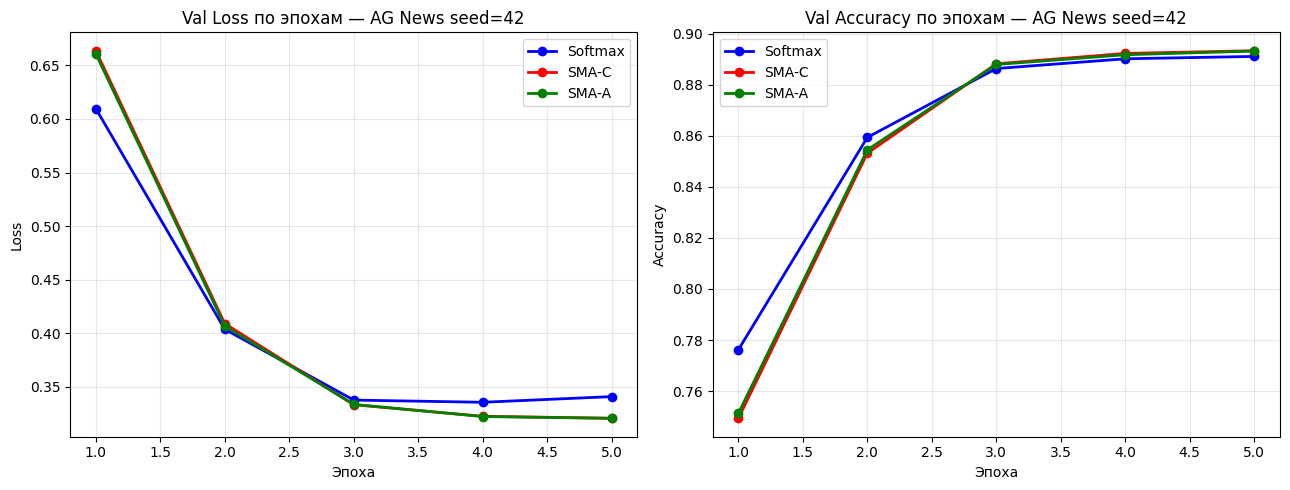

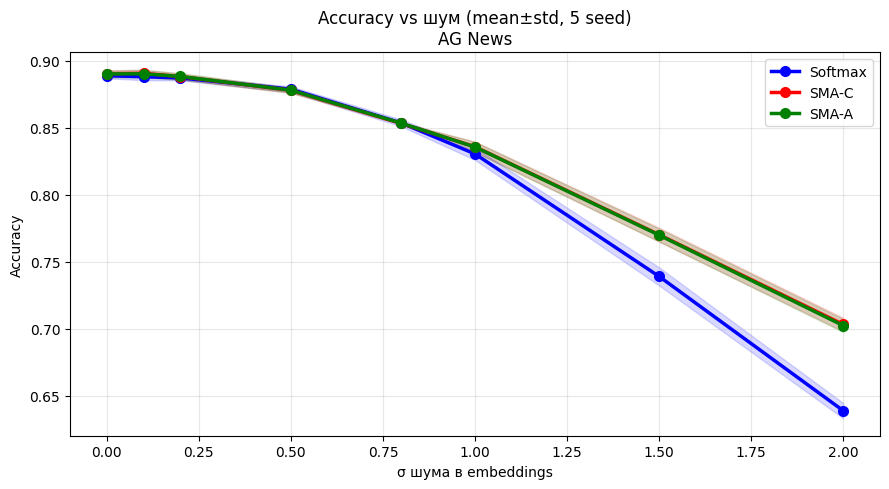

σ              Softmax                  SMA-C                   SMA-A         
----------------------------------------------------------------------
0.0     0.8889 ± 0.0020       0.8904 ± 0.0025       0.8903 ± 0.0027     
0.1     0.8882 ± 0.0026       0.8907 ± 0.0028       0.8903 ± 0.0029     
0.2     0.8873 ± 0.0018       0.8883 ± 0.0022       0.8884 ± 0.0025     
0.5     0.8788 ± 0.0021       0.8780 ± 0.0020       0.8781 ± 0.0019     
0.8     0.8536 ± 0.0025       0.8532 ± 0.0008       0.8534 ± 0.0006     
1.0     0.8305 ± 0.0045       0.8359 ± 0.0038       0.8357 ± 0.0039     
1.5     0.7390 ± 0.0068       0.7702 ± 0.0052       0.7699 ± 0.0049     
2.0     0.6387 ± 0.0057       0.7031 ± 0.0050       0.7023 ± 0.0049     

Деградация при σ=2.0:
  Softmax: -0.2502  (+0.0% vs Softmax)
  SMA-C: -0.1873  (+25.1% vs Softmax)
  SMA-A: -0.1880  (+24.9% vs Softmax)

Время обучения (среднее по seed):
  Softmax: 60.2 ± 0.5 с  (0.0% vs Softmax)
  SMA-C: 85.6 ± 0.2 с  (+42.3% vs Softmax)
  SMA-A

In [ ]:
plot_training_curves(ag_history_seed42, title='AG News seed=42')
plot_noise_robustness(ag_stats, title='AG News', save_name='ag_noise.png')
print_results_table(ag_stats)
print_time_comparison(ag_times)

## Датасет IMDB

In [ ]:
print('='*55)
print('ЭКСПЕРИМЕНТ 3: IMDB (2 класса, длинные тексты)')
print('='*55)

imdb_noise  = {k: [] for k in LABELS}
imdb_times  = {k: [] for k in LABELS}
imdb_last   = {}
imdb_history_seed42 = {}

for seed in SEEDS:
    print(f'\nSeed {seed}')
    for atype in LABELS:
        model, history, noise_accs, t = run_experiment(
            atype, seed,
            imdb_train_loader, imdb_test_loader,
            n_classes=2, max_len=256
        )
        imdb_noise[atype].append(noise_accs)
        imdb_times[atype].append(t)
        imdb_last[atype] = model
        if seed == 42:
            imdb_history_seed42[atype] = history

imdb_stats = {k: get_stats(v) for k, v in imdb_noise.items()}

ЭКСПЕРИМЕНТ 3: IMDB (2 класса, длинные тексты)

Seed 42
  [softmax] Epoch 1/5 val_loss=0.5013 val_acc=0.7502
  [softmax] Epoch 2/5 val_loss=0.3957 val_acc=0.8194
  [softmax] Epoch 3/5 val_loss=0.3916 val_acc=0.8322
  [softmax] Epoch 4/5 val_loss=0.4475 val_acc=0.8330
  [softmax] Epoch 5/5 val_loss=0.4757 val_acc=0.8358
  [sma_c] Epoch 1/5 val_loss=0.5499 val_acc=0.7148
  [sma_c] Epoch 2/5 val_loss=0.4065 val_acc=0.8130
  [sma_c] Epoch 3/5 val_loss=0.3898 val_acc=0.8328
  [sma_c] Epoch 4/5 val_loss=0.4015 val_acc=0.8392
  [sma_c] Epoch 5/5 val_loss=0.3995 val_acc=0.8404
  [sma_a] Epoch 1/5 val_loss=0.5324 val_acc=0.7294
  [sma_a] Epoch 2/5 val_loss=0.4048 val_acc=0.8146
  [sma_a] Epoch 3/5 val_loss=0.3846 val_acc=0.8346
  [sma_a] Epoch 4/5 val_loss=0.4007 val_acc=0.8424
  [sma_a] Epoch 5/5 val_loss=0.3949 val_acc=0.8428

Seed 123
  [softmax] Epoch 1/5 val_loss=0.5068 val_acc=0.7590
  [softmax] Epoch 2/5 val_loss=0.3986 val_acc=0.8238
  [softmax] Epoch 3/5 val_loss=0.4079 val_acc=0.8270


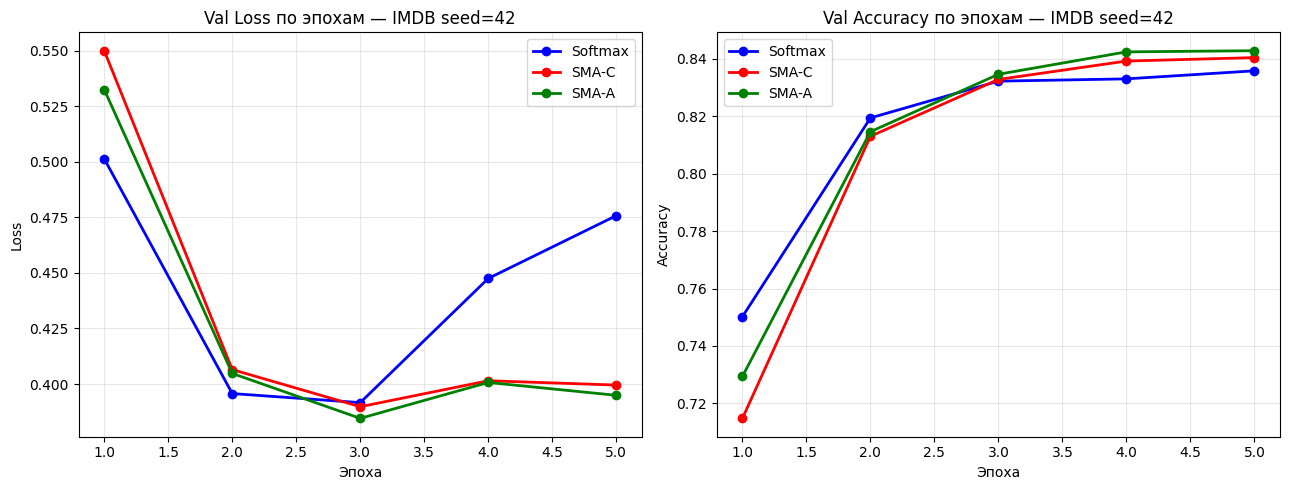

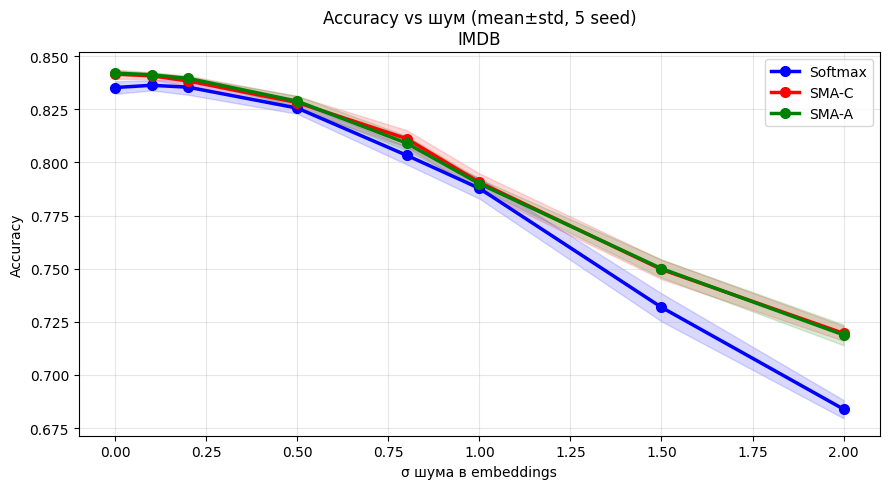

σ              Softmax                  SMA-C                   SMA-A         
----------------------------------------------------------------------
0.0     0.8352 ± 0.0030       0.8415 ± 0.0022       0.8421 ± 0.0007     
0.1     0.8363 ± 0.0024       0.8408 ± 0.0016       0.8412 ± 0.0012     
0.2     0.8354 ± 0.0036       0.8383 ± 0.0026       0.8396 ± 0.0007     
0.5     0.8256 ± 0.0027       0.8282 ± 0.0030       0.8288 ± 0.0026     
0.8     0.8034 ± 0.0043       0.8112 ± 0.0040       0.8091 ± 0.0034     
1.0     0.7878 ± 0.0049       0.7906 ± 0.0042       0.7900 ± 0.0022     
1.5     0.7318 ± 0.0066       0.7496 ± 0.0046       0.7500 ± 0.0043     
2.0     0.6839 ± 0.0043       0.7196 ± 0.0035       0.7188 ± 0.0049     

Деградация при σ=2.0:
  Softmax: -0.1514  (+0.0% vs Softmax)
  SMA-C: -0.1220  (+19.4% vs Softmax)
  SMA-A: -0.1232  (+18.6% vs Softmax)

Время обучения (среднее по seed):
  Softmax: 63.5 ± 0.2 с  (0.0% vs Softmax)
  SMA-C: 103.3 ± 0.2 с  (+62.7% vs Softmax)
  SMA-

In [ ]:
plot_training_curves(imdb_history_seed42, title='IMDB seed=42')
plot_noise_robustness(imdb_stats, title='IMDB', save_name='imdb_noise.png')
print_results_table(imdb_stats)
print_time_comparison(imdb_times)

## Целевой выброс (все датасеты)

Целевой выброс: один токен × amplitude

SST-2:
Амплитуда        Softmax       SMA-C       SMA-A
0                 0.8028      0.7913      0.7913
1                 0.7970      0.7867      0.7913
2                 0.7741      0.7844      0.7924
5                 0.6193      0.7592      0.7764
10                0.5826      0.6995      0.7236
20                0.5275      0.6307      0.6067
50                0.5275      0.5688      0.5631


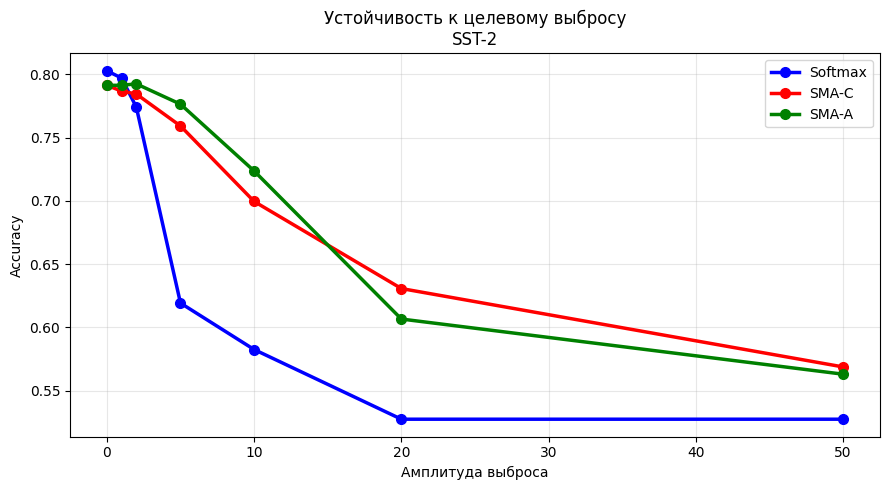


AG News:
Амплитуда        Softmax       SMA-C       SMA-A
0                 0.8909      0.8904      0.8903
1                 0.8880      0.8892      0.8911
2                 0.8642      0.8882      0.8901
5                 0.5414      0.8659      0.8712
10                0.3588      0.8095      0.8163
20                0.3008      0.6639      0.6674
50                0.2716      0.4503      0.4430


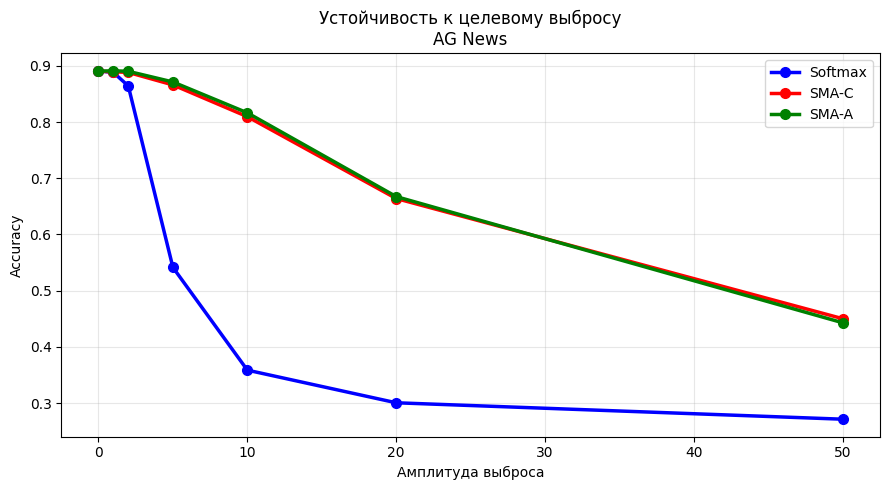


IMDB:
Амплитуда        Softmax       SMA-C       SMA-A
0                 0.8368      0.8400      0.8412
1                 0.8372      0.8384      0.8408
2                 0.8234      0.8374      0.8384
5                 0.6220      0.8358      0.8346
10                0.5344      0.8106      0.8240
20                0.5140      0.7662      0.7742
50                0.5104      0.6586      0.6650


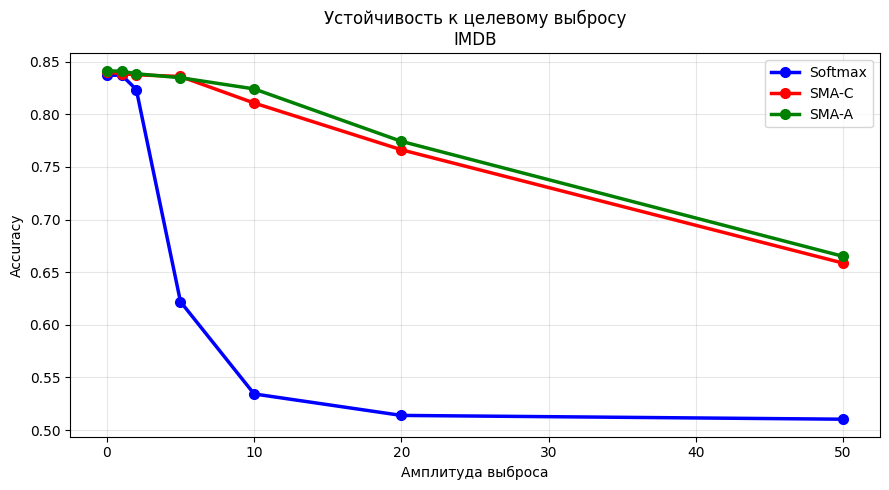

In [ ]:
print('='*55)
print('Целевой выброс: один токен на amplitude')
print('='*55)

for ds_name, last_models, loader in [
    ('SST-2',   sst2_last, sst2_val_loader),
    ('AG News', ag_last,   ag_test_loader),
    ('IMDB',    imdb_last, imdb_test_loader),
]:
    print(f'\n{ds_name}:')
    outlier_res = {}
    for atype, model in last_models.items():
        outlier_res[atype] = [evaluate_outlier(model, loader, a)
                              for a in OUTLIER_AMPLITUDES]
    print(f'{"Амплитуда":<12}', end='')
    for atype in LABELS:
        print(f'  {LABELS[atype]:>10}', end='')
    print()
    for j, amp in enumerate(OUTLIER_AMPLITUDES):
        print(f'{amp:<12}', end='')
        for atype in LABELS:
            print(f'  {outlier_res[atype][j]:>10.4f}', end='')
        print()
    plot_outlier(outlier_res, title=ds_name,
                 save_name=f'outlier_{ds_name.lower().replace(" ","_")}.png')

## Энтропия внимания

Энтропия весов внимания

SST-2:
σ              Softmax         SMA-C         SMA-A
---------------------------------------------
0.0             2.5563        3.1284        3.1284
0.1             2.5536        3.1284        3.1284
0.2             2.5446        3.1284        3.1284
0.5             2.4819        3.1284        3.1284
0.8             2.3776        3.1284        3.1284
1.0             2.2798        3.1284        3.1284
1.5             2.0209        3.1284        3.1284
2.0             1.7601        3.1284        3.1284


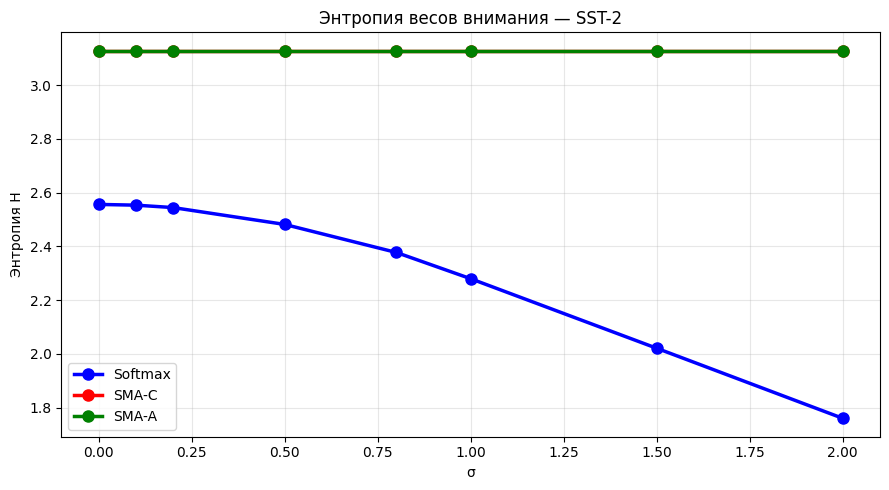


AG News:
σ              Softmax         SMA-C         SMA-A
---------------------------------------------
0.0             3.1989        3.9382        3.9392
0.1             3.1948        3.9382        3.9392
0.2             3.1813        3.9382        3.9392
0.5             3.0902        3.9382        3.9392
0.8             2.9325        3.9382        3.9392
1.0             2.7902        3.9382        3.9392
1.5             2.4003        3.9383        3.9393
2.0             2.0287        3.9383        3.9393


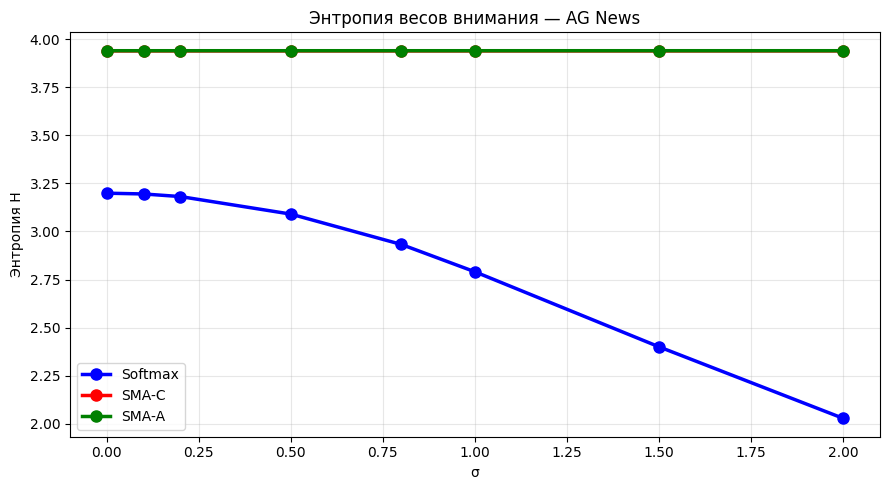


IMDB:
σ              Softmax         SMA-C         SMA-A
---------------------------------------------
0.0             4.1232        5.1696        5.2255
0.1             4.1158        5.1695        5.2255
0.2             4.0907        5.1696        5.2255
0.5             3.9254        5.1696        5.2256
0.8             3.6087        5.1696        5.2257
1.0             3.3441        5.1696        5.2258
1.5             2.5789        5.1697        5.2259
2.0             1.9052        5.1696        5.2260


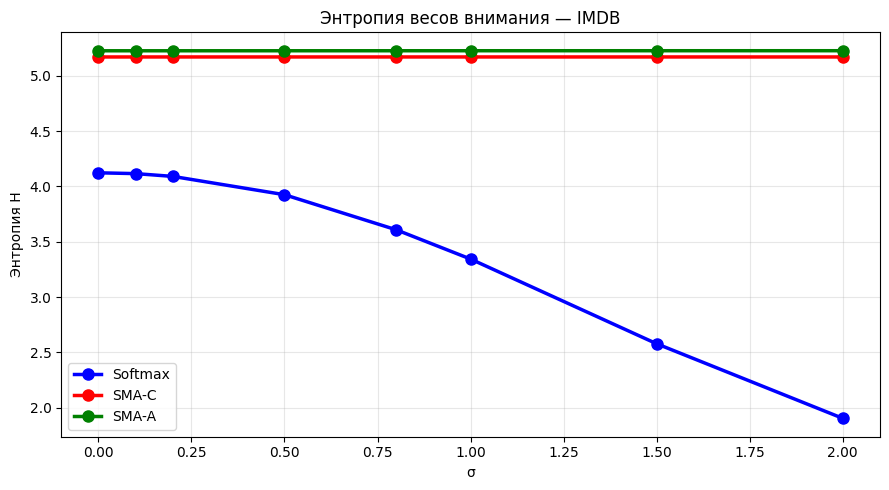

In [ ]:
print('='*55)
print('Энтропия весов внимания')
print('='*55)

for ds_name, last_models, loader in [
    ('SST-2',   sst2_last, sst2_val_loader),
    ('AG News', ag_last,   ag_test_loader),
    ('IMDB',    imdb_last, imdb_test_loader),
]:
    print(f'\n{ds_name}:')
    print(f'{"σ":<8}', end='')
    for atype in LABELS:
        print(f'  {LABELS[atype]:>12}', end='')
    print()
    print('-' * 45)
    ent = {atype: [] for atype in LABELS}
    for n in NOISE_LEVELS:
        print(f'{n:<8.1f}', end='')
        for atype, model in last_models.items():
            h = get_attention_entropy(model, loader, n)
            ent[atype].append(h)
            print(f'  {h:>12.4f}', end='')
        print()

    fig, ax = plt.subplots(figsize=(9, 5))
    for atype, vals in ent.items():
        ax.plot(NOISE_LEVELS, vals, '-o', color=COLORS[atype],
                label=LABELS[atype], lw=2.5, ms=8)
    ax.set_title(f'Энтропия весов внимания — {ds_name}')
    ax.set_xlabel('σ'); ax.set_ylabel('Энтропия H')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'entropy_{ds_name.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## Анализ параметра beta (SMA-C)

In [ ]:
print('='*55)
print('Параметр beta в SMA-C (начальное значение = 1.0)')
print('='*55)
print(f'{"Датасет":<12} {"Слой":^35} {"beta":>10}  {"направление"}')
print('-'*65)
for ds_name, last_models in [
    ('SST-2',   sst2_last),
    ('AG News', ag_last),
    ('IMDB',    imdb_last),
]:
    for name, module in last_models['sma_c'].named_modules():
        if hasattr(module, 'beta'):
            val = module.beta.item()
            print(f'{ds_name:<12} {name:^35} {val:>10.6f}  '
                  f'{"мягче ↓" if val < 1.0 else "контрастнее ↑"}')

Параметр beta в SMA-C (начальное значение = 1.0)
Датасет                     Слой                       beta  направление
-----------------------------------------------------------------
SST-2                layers.0.attention            0.974358  мягче ↓
SST-2                layers.1.attention            0.973788  мягче ↓
AG News              layers.0.attention            1.166020  контрастнее ↑
AG News              layers.1.attention            1.076161  контрастнее ↑
IMDB                 layers.0.attention            1.034487  контрастнее ↑
IMDB                 layers.1.attention            0.931992  мягче ↓


## Сводный график трёх датасетов

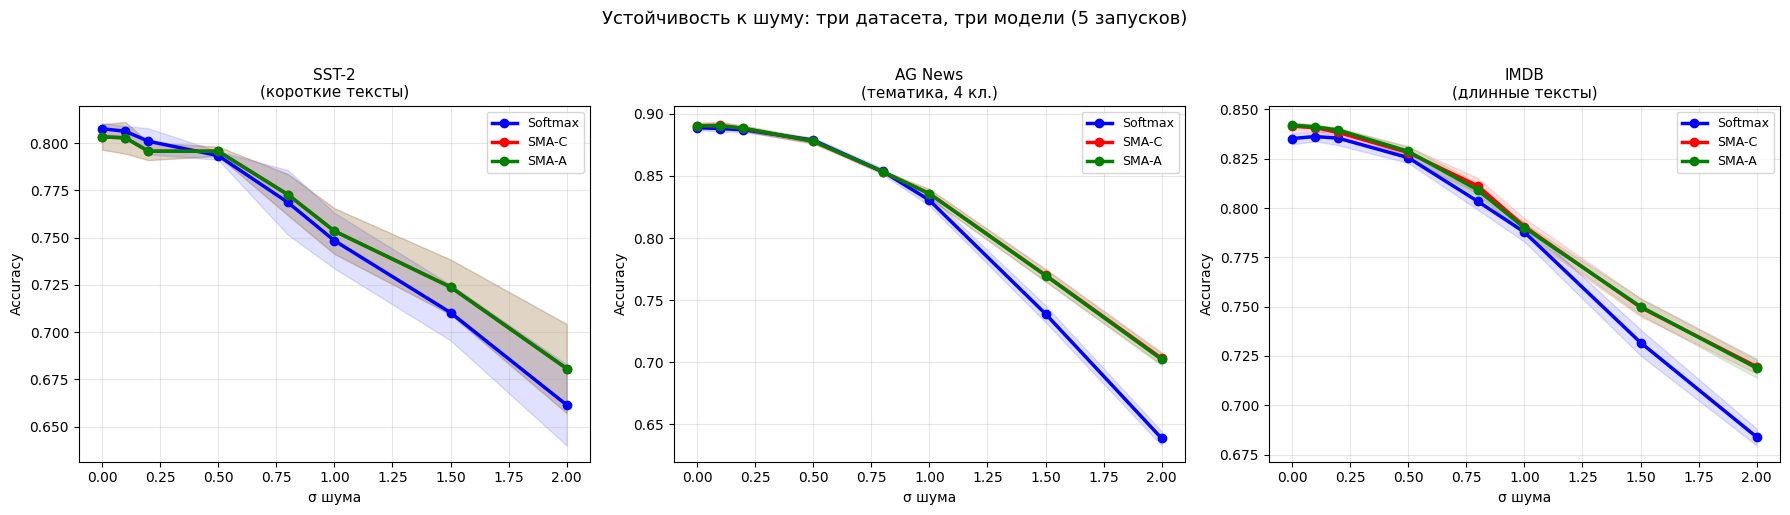


СВОДНАЯ ТАБЛИЦА: деградация accuracy при σ=2.0
Датасет         Softmax      SMA-C      SMA-A        SMA-C        SMA-A
                                                    улучш.       улучш.
-----------------------------------------------------------------
SST-2            0.1461     0.1225     0.1225        16.2%        16.2%
AG News          0.2502     0.1873     0.1880        25.1%        24.9%
IMDB             0.1514     0.1220     0.1232        19.4%        18.6%


In [ ]:
plot_summary(
    {
        'SST-2\n(короткие тексты)':    sst2_stats,
        'AG News\n(тематика, 4 кл.)':  ag_stats,
        'IMDB\n(длинные тексты)':      imdb_stats,
    },
    title=f'Устойчивость к шуму: три датасета, три модели ({len(SEEDS)} запусков)'
)

print('\n' + '='*65)
print('Деградация accuracy при σ=2.0')
print('='*65)
print(f'{"Датасет":<12} {"Softmax":>10} {"SMA-C":>10} {"SMA-A":>10} '
      f'{"SMA-C":>12} {"SMA-A":>12}')
print(f'{"":12} {"":10} {"":10} {"":10} '
      f'{"улучш.":>12} {"улучш.":>12}')
print('-'*65)
for ds_name, stats in [
    ('SST-2',   sst2_stats),
    ('AG News', ag_stats),
    ('IMDB',    imdb_stats),
]:
    degs = {k: stats[k][0][0] - stats[k][0][-1] for k in LABELS}
    base = degs['softmax']
    print(f'{ds_name:<12} '
          f'{degs["softmax"]:>10.4f} '
          f'{degs["sma_c"]:>10.4f} '
          f'{degs["sma_a"]:>10.4f} '
          f'{(base-degs["sma_c"])/base*100:>11.1f}% '
          f'{(base-degs["sma_a"])/base*100:>11.1f}%')
print('='*65)

## Визуализация механизмов внимания

1. Интерактивные слайдеры (ipywidgets): смотрим как меняются веса в реальном времени.
2. Визуализация в стиле слизевика: граф где толщина рёбер равна весу внимания.


In [ ]:
!pip install ipywidgets networkx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 109.3 MB/s eta 0:00:00


In [ ]:
import matplotlib.colors as mcolors
import networkx as nx
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import FancyArrowPatch

In [ ]:
# Вычисление весов внимания из scores

def softmax_weights(scores):
    """Стандартный softmax."""
    return F.softmax(scores, dim=-1)

def sma_c_weights(scores, beta=1.0):
    """SMA Вариант C: tanh-взвешивание."""
    mu    = scores.mean(dim=-1, keepdim=True)
    sigma = scores.std(dim=-1, keepdim=True)
    z     = (scores - mu) / (sigma + 1e-8)
    W     = 1.0 + torch.tanh(torch.tensor(beta) * z)
    return W / (W.sum(dim=-1, keepdim=True) + 1e-8)

def sma_a_weights(scores):
    """SMA Вариант A: логарифмическое взвешивание."""
    bF     = scores.max(dim=-1, keepdim=True).values
    wF     = scores.min(dim=-1, keepdim=True).values
    median = scores.median(dim=-1, keepdim=True).values
    log_t  = torch.log((bF - scores) / (bF - wF + 1e-8) + 1)
    sign   = torch.sign(scores - median).float()
    sign   = torch.where(sign == 0, torch.ones_like(sign), sign)
    W      = 1.0 + sign * log_t
    return W / (W.sum(dim=-1, keepdim=True) + 1e-8)


def get_scores_for_sentence(sentence, model, tokenizer, max_len=128, noise_std=0.0):
    """
    Прогоняет предложение через модель и возвращает:
    - tokens: список токенов (без паддинга)
    - scores: матрица attention scores первой головы первого слоя
    """
    model.eval()
    enc = tokenizer(sentence, return_tensors='pt',
                    padding='max_length', truncation=True, max_length=max_len)
    ids = enc['input_ids'].to(device)
    msk = enc['attention_mask'].to(device)
    real_len = msk.sum().item()

    with torch.no_grad():
        pos = torch.arange(ids.shape[1], device=device).unsqueeze(0)
        x   = model.embedding(ids) + model.pos_embedding(pos)
        if noise_std > 0:
            x = x + torch.randn_like(x) * noise_std * msk.unsqueeze(-1).float()
        x    = model.dropout(x)
        attn = model.layers[0].attention
        B, T = 1, ids.shape[1]
        Q = attn.W_q(x).view(B, T, attn.n_heads, attn.d_k).transpose(1, 2)
        K = attn.W_k(x).view(B, T, attn.n_heads, attn.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (attn.d_k ** 0.5)
        # Берём первую голову, только реальные токены
        sc = scores[0, 0, :real_len, :real_len].cpu()

    tokens = tokenizer.convert_ids_to_tokens(ids[0, :real_len].cpu().tolist())
    tokens = [t.replace('##', '') for t in tokens]
    return tokens, sc

### Интерактивная тепловая карта

In [ ]:
def make_interactive_heatmap(sentence, model_softmax, model_sma_c,
                              model_sma_a, tokenizer):
    """
    Слайдер шума: меняются карты внимания моделей.
    Слайдер beta: меняется острота SMA-C.
    """
    noise_slider = widgets.FloatSlider(
        value=0.0, min=0.0, max=2.0, step=0.1,
        description='Шум σ:', continuous_update=False,
        layout=widgets.Layout(width='500px')
    )
    beta_slider = widgets.FloatSlider(
        value=1.0, min=0.1, max=3.0, step=0.1,
        description='Beta (SMA-C):', continuous_update=False,
        layout=widgets.Layout(width='500px')
    )

    output = widgets.Output()

    def update(noise_std, beta):
        with output:
            output.clear_output(wait=True)
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))

            for ax, model, title, get_w in [
                (axes[0], model_softmax, 'Softmax',
                 lambda sc: softmax_weights(sc)),
                (axes[1], model_sma_c,  f'SMA-C (β={beta:.1f})',
                 lambda sc: sma_c_weights(sc, beta)),
                (axes[2], model_sma_a,  'SMA-A (log)',
                 lambda sc: sma_a_weights(sc)),
            ]:
                tokens, sc = get_scores_for_sentence(
                    sentence, model, tokenizer, noise_std=noise_std
                )
                w = get_w(sc).numpy()

                im = ax.imshow(w, cmap='YlOrRd', vmin=0, vmax=w.max() + 0.01,
                               aspect='auto')
                ax.set_xticks(range(len(tokens)))
                ax.set_yticks(range(len(tokens)))
                ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
                ax.set_yticklabels(tokens, fontsize=8)
                ax.set_title(title, fontsize=12, fontweight='bold')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

                H = -(w * np.log(w + 1e-9)).sum(axis=-1).mean()
                ax.set_xlabel(f'Энтропия H = {H:.3f}', fontsize=10)

            plt.suptitle(
                f'Веса внимания при шуме σ={noise_std:.1f}\n',
                fontsize=12, y=1.02
            )
            plt.tight_layout()
            plt.show()

    interactive = widgets.interactive(update,
                                       noise_std=noise_slider,
                                       beta=beta_slider)
    display(widgets.VBox([
        widgets.HTML('<h3>Интерактивная карта весов внимания</h3>'),
        widgets.HTML(f'<b>Предложение:</b> {sentence}'),
        noise_slider, beta_slider, output
    ]))
    update(0.0, 1.0)

### Граф весов внимания как сети слизевика

In [ ]:
def plot_slime_mould_graph(sentence, model, tokenizer, noise_std=0.0,
                            title='', weight_fn=None, threshold=0.05,
                            save_name=None):
    """
    Визуализирует веса внимания как сеть:
    - Узлы = токены
    - Рёбра = веса внимания
    - Толщина ребра = вес
    - Цвет ребра = интенсивность
    """
    tokens, sc = get_scores_for_sentence(sentence, model, tokenizer,
                                          noise_std=noise_std)
    w = weight_fn(sc).numpy() if weight_fn else softmax_weights(sc).numpy()
    T = len(tokens)

    G = nx.DiGraph()
    for i, tok in enumerate(tokens):
        G.add_node(i, label=tok)

    edge_weights = []
    for i in range(T):
        for j in range(T):
            if w[i, j] > threshold and i != j:
                G.add_edge(i, j, weight=w[i, j])
                edge_weights.append(w[i, j])

    fig, ax = plt.subplots(figsize=(12, 8))

    # Круговое расположение токенов
    pos = nx.circular_layout(G)

    # Узлы
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color='#2d6a9f',
                           node_size=800, alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax,
                            labels={i: tokens[i] for i in range(T)},
                            font_color='white', font_size=8,
                            font_weight='bold')

    # Рёбра: толщина и цвет по весу
    if edge_weights:
        max_w = max(edge_weights)
        cmap  = plt.cm.YlOrRd
        edges = list(G.edges(data=True))
        for src, dst, data in edges:
            wt    = data['weight']
            width = (wt / max_w) * 8 + 0.5   # от 0.5 до 8.5 пикселей
            alpha = 0.3 + 0.7 * (wt / max_w)  # от 0.3 до 1.0
            color = cmap(wt / max_w)
            nx.draw_networkx_edges(
                G, pos, ax=ax,
                edgelist=[(src, dst)],
                width=width, alpha=alpha,
                edge_color=[color],
                arrows=True, arrowsize=15,
                connectionstyle='arc3,rad=0.1'
            )

    # Легенда с примерами толщины
    for wt_ex, label in [(0.3, 'слабая связь'), (0.6, 'средняя'), (1.0, 'сильная')]:
        ax.plot([], [], linewidth=(wt_ex * 8 + 0.5),
                color=plt.cm.YlOrRd(wt_ex), label=label, alpha=0.8)
    ax.legend(loc='upper left', fontsize=9, title='Сила связи')

    # Средняя энтропия
    H = -(w * np.log(w + 1e-9)).sum(axis=-1).mean()
    ax.set_title(
        f'{title}\n'
        f'σ={noise_std:.1f} | порог={threshold} | '
        f'рёбер={len(edge_weights)} | энтропия H={H:.3f}',
        fontsize=12, fontweight='bold', pad=20
    )
    ax.set_facecolor('#0a1628')
    fig.patch.set_facecolor('#0a1628')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    plt.tight_layout()
    if save_name: plt.savefig(save_name, dpi=150, bbox_inches='tight', facecolor='#0a1628')
    plt.show()
    return H


def compare_slime_graphs(sentence, models_dict, tokenizer,
                          noise_levels_viz=(0.0, 1.0, 2.0), threshold=0.04):
    """
    Сравнительная визуализация: строки - модели, столбцы - уровни шума.
    """
    weight_fns = {
        'softmax': softmax_weights,
        'sma_c':   lambda sc: sma_c_weights(sc, beta=1.0),
        'sma_a':   sma_a_weights,
    }

    n_rows = len(models_dict)
    n_cols = len(noise_levels_viz)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(6 * n_cols, 5 * n_rows),
                              facecolor='#0a1628')

    for row, (atype, model) in enumerate(models_dict.items()):
        for col, noise_std in enumerate(noise_levels_viz):
            ax = axes[row, col] if n_rows > 1 else axes[col]

            tokens, sc = get_scores_for_sentence(
                sentence, model, tokenizer, noise_std=noise_std
            )
            w  = weight_fns[atype](sc).numpy()
            T  = len(tokens)
            H  = -(w * np.log(w + 1e-9)).sum(axis=-1).mean()

            G = nx.DiGraph()
            for i in range(T): G.add_node(i)
            edge_ws = []
            for i in range(T):
                for j in range(T):
                    if w[i, j] > threshold and i != j:
                        G.add_edge(i, j, weight=w[i, j])
                        edge_ws.append(w[i, j])

            pos = nx.circular_layout(G)
            ax.set_facecolor('#0a1628')

            nx.draw_networkx_nodes(G, pos, ax=ax,
                                   node_color='#4a9eda', node_size=500, alpha=0.9)
            nx.draw_networkx_labels(G, pos, ax=ax,
                                    labels={i: tokens[i] for i in range(T)},
                                    font_color='white', font_size=7,
                                    font_weight='bold')
            if edge_ws:
                max_w = max(edge_ws)
                for src, dst, data in G.edges(data=True):
                    wt = data['weight']
                    nx.draw_networkx_edges(
                        G, pos, ax=ax,
                        edgelist=[(src, dst)],
                        width=(wt / max_w) * 6 + 0.3,
                        alpha=0.3 + 0.7 * (wt / max_w),
                        edge_color=[plt.cm.YlOrRd(wt / max_w)],
                        arrows=True, arrowsize=12,
                        connectionstyle='arc3,rad=0.1'
                    )

            title_color = 'white'
            ax.set_title(
                f'{LABELS[atype]}  |  σ={noise_std:.1f}  |  H={H:.3f}',
                color=title_color, fontsize=10, fontweight='bold', pad=10
            )
            ax.tick_params(left=False, bottom=False,
                           labelleft=False, labelbottom=False)

    plt.suptitle(
        f'Сеть весов внимания — как трубки слизевика\n'
        f'Толщина ребра = сила связи между токенами\n'
        f'"{sentence}"',
        color='white', fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.savefig('slime_mould_comparison.png', dpi=150,
                bbox_inches='tight', facecolor='#0a1628')
    plt.show()

Используем модели обученные на SST-2

Предложение для визуализации:
  "the film is not so much disappointing as it is dull"



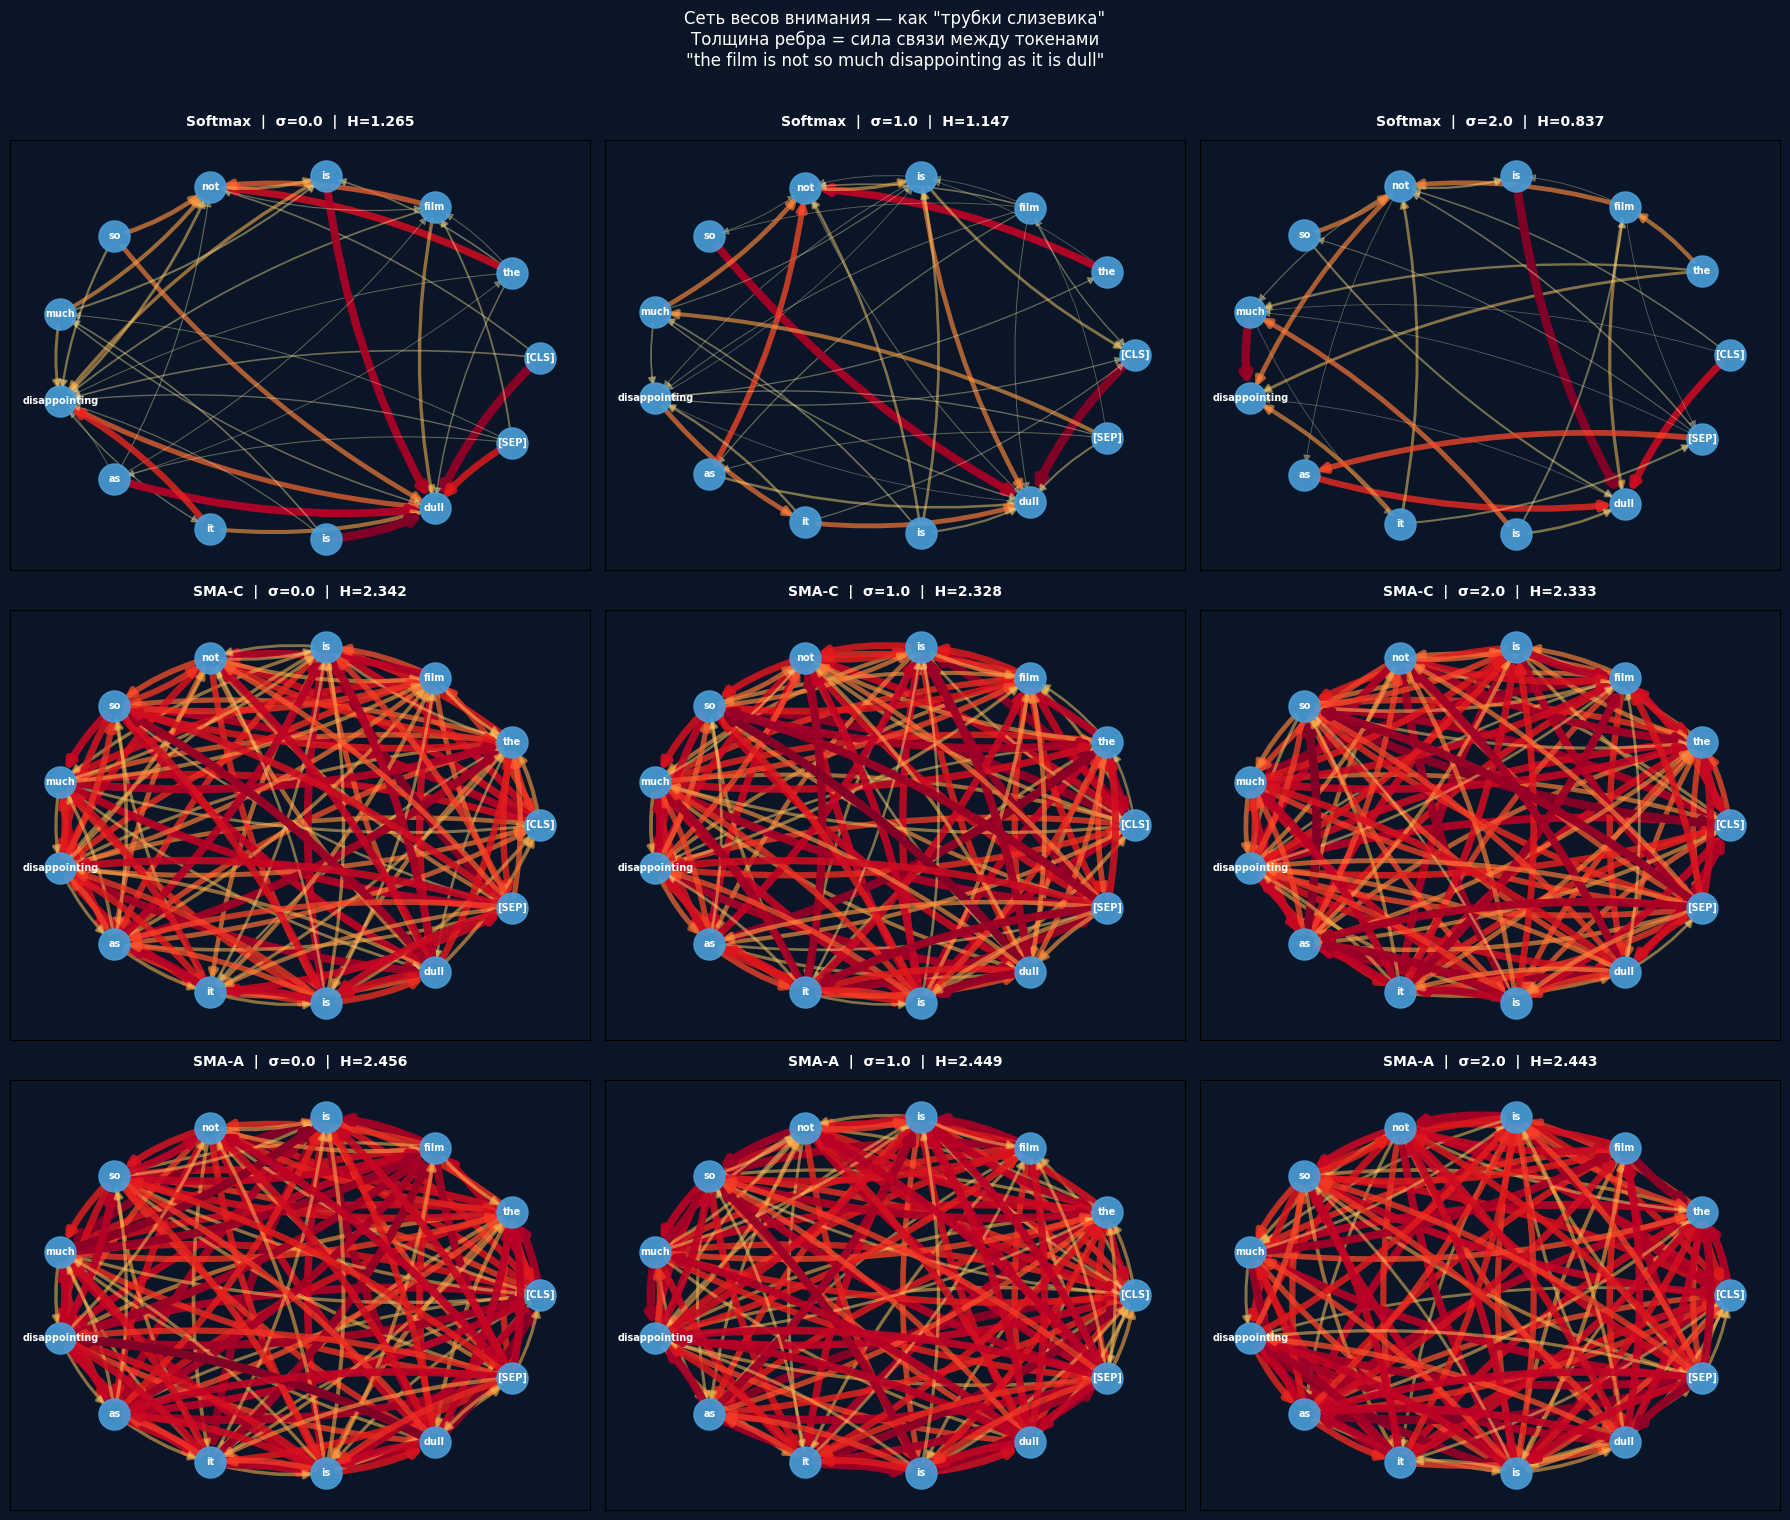

In [ ]:
# Выбираем короткое информативное предложение для визуализации
VIZ_SENTENCE = "the film is not so much disappointing as it is dull"

print('Предложение для визуализации:')
print(f'  "{VIZ_SENTENCE}"\n')

# Интерактивная тепловая карта ---
make_interactive_heatmap(
    VIZ_SENTENCE,
    sst2_last['softmax'],
    sst2_last['sma_c'],
    sst2_last['sma_a'],
    tokenizer
)


# Сравнительный граф
compare_slime_graphs(
    VIZ_SENTENCE,
    {k: sst2_last[k] for k in ['softmax', 'sma_c', 'sma_a']},
    tokenizer,
    noise_levels_viz=(0.0, 1.0, 2.0),
    threshold=0.04
)

## Сравнение SMA-C, Softmax, Sparsemax и α-entmax.

Из предыдущих ячеек используются: классы SMAAttentionC, SoftmaxAttention; функции set_seed, eval_noise, get_attention_entropy; переменные device, VOCAB_SIZE, tokenizer, SEEDS, NOISE_LEVELS; ag_train_loader, ag_test_loader (если уже загружены).

In [ ]:
!pip install entmax -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
import random
from torch.utils.data import DataLoader, Subset
from datasets import load_dataset
from entmax import sparsemax, entmax15  # entmax15 = α-entmax с α=1.5

Альтернативные механизмы attention, заменяющие стандартный softmax на разреживающие функции распределения весов.

`SparsemaxAttention` использует sparsemax-преобразование, которое проецирует attention-скоры на вероятностный симплекс и зануляет незначимые токены, делая распределение более разреженным и интерпретируемым.

`EntmaxAttention` использует α-entmax (в данном случае entmax-1.5), который является промежуточным вариантом между softmax и sparsemax: сохраняет дифференцируемость, но также позволяет частичное обнуление весов внимания, обеспечивая баланс между плотностью и разреженностью распределения.


In [ ]:
class SparsemaxAttention(nn.Module):
    """Sparsemax: проецирует scores на симплекс, обнуляет нерелевантные токены."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        w = sparsemax(scores, dim=-1)
        w = self.dropout(w)
        out = torch.matmul(w, V)
        return self.W_o(out.transpose(1, 2).contiguous().view(B, T, self.d_model))


class EntmaxAttention(nn.Module):
    """α-entmax (α=1.5): между softmax и sparsemax, частичное разреживание."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        w = entmax15(scores, dim=-1)
        w = self.dropout(w)
        out = torch.matmul(w, V)
        return self.W_o(out.transpose(1, 2).contiguous().view(B, T, self.d_model))

Архитектура трансформера.

`TransformerBlockComp` представляет один блок трансформера, состоящий из выбранного варианта attention (softmax, SMA, sparsemax или entmax), feed-forward сети и residual-соединений с LayerNorm.

`TextClassifierComp` полная модель для классификации текста на основе трансформера. Включает эмбеддинги токенов и позиций, несколько слоёв `TransformerBlockComp`, dropout для регуляризации и финальный классификатор.


In [ ]:
class TransformerBlockComp(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1, atype='softmax'):
        super().__init__()
        if atype == 'softmax':
            self.attention = SoftmaxAttention(d_model, n_heads, dropout)
        elif atype == 'sma_c':
            self.attention = SMAAttentionC(d_model, n_heads, dropout)
        elif atype == 'sparsemax':
            self.attention = SparsemaxAttention(d_model, n_heads, dropout)
        elif atype == 'entmax':
            self.attention = EntmaxAttention(d_model, n_heads, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attention(x, mask))
        x = self.norm2(x + self.ff(x))
        return x


class TextClassifierComp(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=2,
                 d_ff=256, max_len=128, n_classes=4, dropout=0.1, atype='softmax'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            TransformerBlockComp(d_model, n_heads, d_ff, dropout, atype)
            for _ in range(n_layers)
        ])
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, input_ids, attention_mask=None, noise_std=0.0):
        B, T = input_ids.shape
        pos = torch.arange(T, device=input_ids.device).unsqueeze(0)
        x = self.embedding(input_ids) + self.pos_embedding(pos)
        if noise_std > 0.0:
            noise = torch.randn_like(x) * noise_std
            if attention_mask is not None:
                noise = noise * attention_mask.unsqueeze(-1).float()
            x = x + noise
        x = self.dropout(x)
        mask = attention_mask.unsqueeze(1).unsqueeze(2) if attention_mask is not None else None
        for layer in self.layers:
            x = layer(x, mask)
        if attention_mask is not None:
            m = attention_mask.unsqueeze(-1).float()
            x = (x * m).sum(1) / m.sum(1).clamp(min=1)
        else:
            x = x.mean(1)
        return self.classifier(x)

Данные AG News

In [ ]:
MAX_LEN_AG = 128
BATCH_SIZE_AG = 64
N_CLASSES_AG = 4
N_EPOCHS_COMP = 5

try:
    _ = ag_train_loader
    print('AG News loaders уже загружены')
except NameError:
    random.seed(42)
    ag_ds = load_dataset('ag_news')
    def prep_ag(split):
        d = ag_ds[split].map(
            lambda x: tokenizer(x['text'], padding='max_length',
                                truncation=True, max_length=MAX_LEN_AG),
            batched=True
        )
        d.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
        return d
    ag_train_full = prep_ag('train')
    ag_test_full  = prep_ag('test')
    train_idx = random.sample(range(len(ag_train_full)), 40000)
    test_idx  = random.sample(range(len(ag_test_full)),  7600)
    ag_train_loader = DataLoader(Subset(ag_train_full, train_idx),
                                  batch_size=BATCH_SIZE_AG, shuffle=True, num_workers=2)
    ag_test_loader  = DataLoader(Subset(ag_test_full, test_idx),
                                  batch_size=BATCH_SIZE_AG, num_workers=2)
    print(f'Батчей: train={len(ag_train_loader)}, test={len(ag_test_loader)}')

AG News loaders уже загружены


Функции обучения и оценки

In [ ]:
def train_and_eval_comp(atype, seed):
    set_seed(seed)
    model = TextClassifierComp(
        VOCAB_SIZE, 128, 4, 2, 256, MAX_LEN_AG, N_CLASSES_AG, 0.1, atype
    ).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    sch = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=1e-3, total_steps=len(ag_train_loader) * N_EPOCHS_COMP
    )
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    for epoch in range(N_EPOCHS_COMP):
        model.train()
        for batch in ag_train_loader:
            ids = batch['input_ids'].to(device)
            msk = batch['attention_mask'].to(device)
            lbl = batch['label'].to(device)
            opt.zero_grad()
            F.cross_entropy(model(ids, msk), lbl).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sch.step()

    if device.type == 'cuda':
        torch.cuda.synchronize()
    train_time = time.perf_counter() - t0

    # val accuracy и noise robustness
    noise_levels = [0.0, 0.1, 0.2, 0.5, 0.8, 1.0, 1.5, 2.0]
    accs, losses = [], []
    model.eval()
    with torch.no_grad():
        for ns in noise_levels:
            correct, total_loss, total = 0, 0.0, 0
            for batch in ag_test_loader:
                ids = batch['input_ids'].to(device)
                msk = batch['attention_mask'].to(device)
                lbl = batch['label'].to(device)
                logits = model(ids, msk, noise_std=ns)
                total_loss += F.cross_entropy(logits, lbl).item() * lbl.size(0)
                correct += (logits.argmax(-1) == lbl).sum().item()
                total += lbl.size(0)
            accs.append(correct / total)
            losses.append(total_loss / total)

    return model, accs, losses, train_time


@torch.no_grad()
def eval_outlier_comp(model, amplitude):
    model.eval()
    correct, total = 0, 0
    for batch in ag_test_loader:
        ids = batch['input_ids'].to(device)
        msk = batch['attention_mask'].to(device)
        lbl = batch['label'].to(device)
        if amplitude > 0:
            B, T = ids.shape
            pos = torch.arange(T, device=device).unsqueeze(0)
            x = model.embedding(ids) + model.pos_embedding(pos)
            lengths = msk.sum(1).long()
            noise = torch.randn(B, x.size(-1), device=device) * amplitude
            for b in range(B):
                p = torch.randint(0, lengths[b].item(), (1,)).item()
                x[b, p] += noise[b]
            x = model.dropout(x)
            mask4 = msk.unsqueeze(1).unsqueeze(2)
            for layer in model.layers:
                x = layer(x, mask4)
            m_exp = msk.unsqueeze(-1).float()
            x = (x * m_exp).sum(1) / m_exp.sum(1).clamp(min=1)
            logits = model.classifier(x)
        else:
            logits = model(ids, msk)
        correct += (logits.argmax(-1) == lbl).sum().item()
        total += lbl.size(0)
    return correct / total


def get_entropy_comp(model, n_batches=5, noise_std=0.0):
    """Энтропия весов внимания первого слоя."""
    model.eval()
    vals = []
    for i, batch in enumerate(ag_test_loader):
        if i >= n_batches: break
        ids = batch['input_ids'].to(device)
        msk = batch['attention_mask'].to(device)
        B, T = ids.shape
        with torch.no_grad():
            pos = torch.arange(T, device=device).unsqueeze(0)
            x = model.embedding(ids) + model.pos_embedding(pos)
            if noise_std > 0:
                x = x + torch.randn_like(x) * noise_std * msk.unsqueeze(-1).float()
            x = model.dropout(x)
            attn = model.layers[0].attention
            mask4 = msk.unsqueeze(1).unsqueeze(2)
            Q = attn.W_q(x).view(B, T, attn.n_heads, attn.d_k).transpose(1, 2)
            K = attn.W_k(x).view(B, T, attn.n_heads, attn.d_k).transpose(1, 2)
            sc = torch.matmul(Q, K.transpose(-2, -1)) / (attn.d_k ** 0.5)
            sc_m = sc.masked_fill(mask4 == 0, -1e9)
            if isinstance(attn, SMAAttentionC):
                w = attn.sma_weights(sc, mask4)
            elif isinstance(attn, SparsemaxAttention):
                w = sparsemax(sc_m, dim=-1)
            elif isinstance(attn, EntmaxAttention):
                w = entmax15(sc_m, dim=-1)
            else:
                w = torch.nan_to_num(F.softmax(sc_m, dim=-1), nan=0.0)
            H = -(w * torch.log(w + 1e-9)).sum(-1).mean().item()
            vals.append(H)
    return np.mean(vals)

Запуск multi-seed для всех 4 моделей

In [ ]:
ATYPES = ['softmax', 'sparsemax', 'entmax', 'sma_c']
LABELS_COMP = {
    'softmax':   'Softmax',
    'sparsemax': 'Sparsemax',
    'entmax':    'α-entmax (1.5)',
    'sma_c':     'SMA-C'
}
COLORS_COMP = {
    'softmax':   'blue',
    'sparsemax': 'orange',
    'entmax':    'purple',
    'sma_c':     'red'
}
NOISE_LEVELS_COMP = [0.0, 0.1, 0.2, 0.5, 0.8, 1.0, 1.5, 2.0]
OUTLIER_AMP_COMP  = [0, 1, 2, 5, 10, 20, 50]

comp_accs  = {a: [] for a in ATYPES}
comp_times = {a: [] for a in ATYPES}
comp_last  = {}

for seed in SEEDS:
    print(f'\nSeed {seed}')
    for atype in ATYPES:
        model, accs, _, t = train_and_eval_comp(atype, seed)
        comp_accs[atype].append(accs)
        comp_times[atype].append(t)
        comp_last[atype] = model
        print(f'  {LABELS_COMP[atype]}: acc={accs[0]:.4f}  time={t:.1f}s')

def mstd(lst):
    a = np.array(lst)
    return a.mean(0), a.std(0)

stats_comp = {a: mstd(comp_accs[a]) for a in ATYPES}


Seed 42
  Softmax: acc=0.8917  time=57.3s
  Sparsemax: acc=0.8824  time=76.9s
  α-entmax (1.5): acc=0.8864  time=89.9s
  SMA-C (наш): acc=0.8914  time=81.0s

Seed 123
  Softmax: acc=0.8859  time=57.1s
  Sparsemax: acc=0.8764  time=76.5s
  α-entmax (1.5): acc=0.8795  time=88.0s
  SMA-C (наш): acc=0.8891  time=80.7s

Seed 7
  Softmax: acc=0.8922  time=56.9s
  Sparsemax: acc=0.8795  time=76.5s
  α-entmax (1.5): acc=0.8817  time=88.0s
  SMA-C (наш): acc=0.8920  time=80.9s

Seed 256
  Softmax: acc=0.8866  time=57.2s
  Sparsemax: acc=0.8746  time=76.6s
  α-entmax (1.5): acc=0.8809  time=88.2s
  SMA-C (наш): acc=0.8878  time=81.0s

Seed 999
  Softmax: acc=0.8903  time=57.4s
  Sparsemax: acc=0.8836  time=76.6s
  α-entmax (1.5): acc=0.8876  time=88.0s
  SMA-C (наш): acc=0.8908  time=80.7s


In [ ]:
# Целевой выброс
outlier_res = {}
for atype in ATYPES:
    outlier_res[atype] = [eval_outlier_comp(comp_last[atype], amp) for amp in OUTLIER_AMP_COMP]

# Энтропия
entropy_by_noise = {a: [] for a in ATYPES}
for ns in NOISE_LEVELS_COMP:
    for atype in ATYPES:
        entropy_by_noise[atype].append(get_entropy_comp(comp_last[atype], noise_std=ns))

# Таблица результатов
print('\n' + '='*72)
print(f'{"Метод":<20} {"Acc σ=0":>10} {"Acc σ=2.0":>10} {"Деград.":>10} {"Время (s)":>12}')
print('-'*72)
base_time = np.mean(comp_times['softmax'])
for atype in ATYPES:
    m, s = stats_comp[atype]
    deg = m[0] - m[-1]
    t_mean = np.mean(comp_times[atype])
    overhead = (t_mean / base_time - 1) * 100
    print(f'{LABELS_COMP[atype]:<20} '
          f'{m[0]:>10.4f} {m[-1]:>10.4f} {deg:>10.4f} '
          f'{t_mean:>8.1f}s ({overhead:+.0f}%)')
print('='*72)


Метод                   Acc σ=0  Acc σ=2.0    Деград.    Время (s)
------------------------------------------------------------------------
Softmax                  0.8893     0.6375     0.2518     57.2s (+0%)
Sparsemax                0.8793     0.6242     0.2551     76.6s (+34%)
α-entmax (1.5)           0.8832     0.6228     0.2604     88.4s (+55%)
SMA-C                    0.8902     0.7026     0.1876     80.9s (+41%)


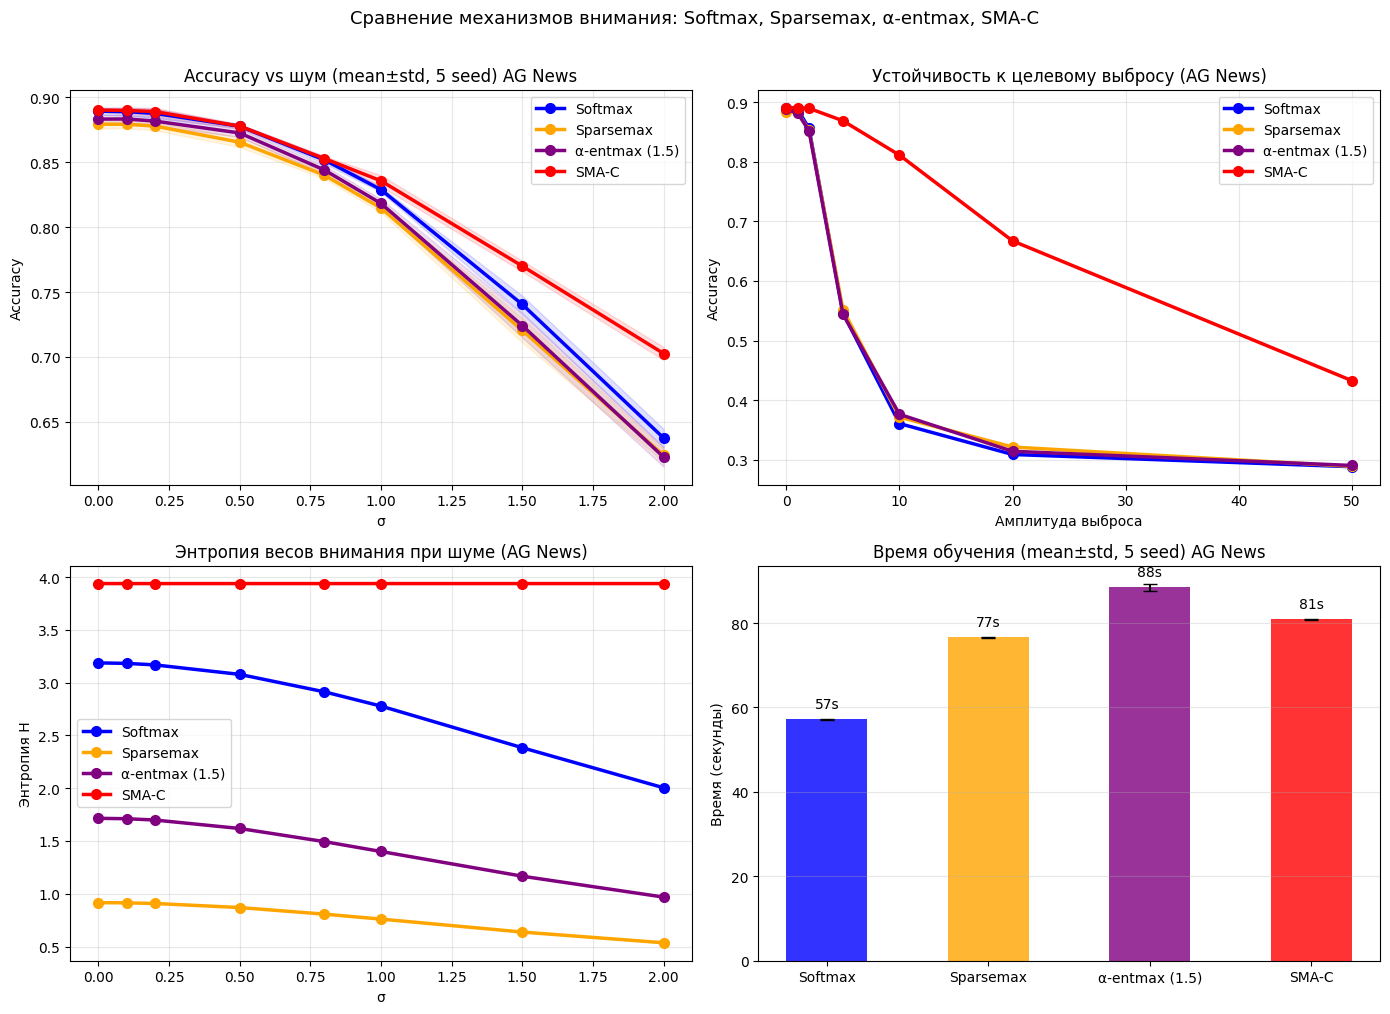

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy vs шум
for a in ATYPES:
    m, s = stats_comp[a]
    axes[0, 0].plot(NOISE_LEVELS_COMP, m, '-o', color=COLORS_COMP[a],
                    label=LABELS_COMP[a], lw=2.5, ms=7)
    axes[0, 0].fill_between(NOISE_LEVELS_COMP, m-s, m+s, alpha=0.12, color=COLORS_COMP[a])
axes[0, 0].set_title(f'Accuracy vs шум (mean±std, {len(SEEDS)} seed) AG News')
axes[0, 0].set_xlabel('σ'); axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend(fontsize=10); axes[0, 0].grid(True, alpha=0.3)

# 2. Целевой выброс
for a in ATYPES:
    axes[0, 1].plot(OUTLIER_AMP_COMP, outlier_res[a], '-o',
                    color=COLORS_COMP[a], label=LABELS_COMP[a], lw=2.5, ms=7)
axes[0, 1].set_title('Устойчивость к целевому выбросу (AG News)')
axes[0, 1].set_xlabel('Амплитуда выброса'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(fontsize=10); axes[0, 1].grid(True, alpha=0.3)

# 3. Энтропия весов внимания
for a in ATYPES:
    axes[1, 0].plot(NOISE_LEVELS_COMP, entropy_by_noise[a], '-o',
                    color=COLORS_COMP[a], label=LABELS_COMP[a], lw=2.5, ms=7)
axes[1, 0].set_title('Энтропия весов внимания при шуме (AG News)')
axes[1, 0].set_xlabel('σ'); axes[1, 0].set_ylabel('Энтропия H')
axes[1, 0].legend(fontsize=10); axes[1, 0].grid(True, alpha=0.3)

# 4. Время обучения (bar chart)
methods = [LABELS_COMP[a] for a in ATYPES]
times_mean = [np.mean(comp_times[a]) for a in ATYPES]
times_std  = [np.std(comp_times[a]) for a in ATYPES]
bars = axes[1, 1].bar(methods, times_mean, yerr=times_std,
                       color=[COLORS_COMP[a] for a in ATYPES],
                       alpha=0.8, capsize=5, width=0.5)
for bar, t in zip(bars, times_mean):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    f'{t:.0f}s', ha='center', va='bottom', fontsize=10)
axes[1, 1].set_title(f'Время обучения (mean±std, {len(SEEDS)} seed) AG News')
axes[1, 1].set_ylabel('Время (секунды)'); axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Сравнение механизмов внимания: Softmax, Sparsemax, α-entmax, SMA-C',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()